[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter13_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 13: Foundation models and conformal prediction

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Pretraining: the Chronos tokeniser; accuracy against model size.
- Zero-shot forecasts of open models on a CPU (Chronos-Bolt, Chronos-2, TimesFM 2.5, TiRex): Romanian load, EU inflation, realised variance; covariates in context; windows after the model releases; multiple testing.
- Conformal prediction: split conformal and CQR; weighted conformal, ACI, conformal PID and EnbPI for dependent data; coverage diagnostics; calibration of foundation-model intervals and VaR.
- The evaluation windows are shorter than on the slides (constants in the first code cell), so that everything runs in minutes on a CPU; a model whose library does not install is skipped.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
# open foundation models on a CPU (Colab: installed here if missing; a model that does not install is skipped)
%pip install -q chronos-forecasting timesfm tirex-ts

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The engine and the data helpers

- Scores and tests: `pinball`, `crps_q`, `qlike`, `dm_test`, `mcs`, `holm`, `bh`, `kupiec`, `christoffersen`.
- Baselines: `ar_forecast`, `ets_forecast`, `har_forecast`, `garch11_fit`; deep baselines `DLinear`, `NBeats`.
- Foundation models: `fm_load`, `fm_forecast` (one interface, quantiles at fixed levels), `chronos_tokenise`.
- Conformal: `conformal_quantile`, `split_conformal`, `cqr`, `online_threshold` (static, rolling, weighted, ACI, quantile tracking, PID), `enbpi`.
- Data: Energy-Charts load, Open-Meteo temperature, Eurostat HICP, Binance and Oxford-Man realised variance, EODHD closes.

In [6]:
import io
import math
import hashlib
import time
import inspect
import types
try:
    import torch
    from torch import nn
    TORCH = True
except ImportError:
    torch = None
    nn = types.SimpleNamespace(Module=object)
    TORCH = False
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..') if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
LOAD_API = 'https://api.energy-charts.info/public_power?country=ro&start={a}&end={b}'
METEO_API = 'https://archive-api.open-meteo.com/v1/archive?latitude=44.43&longitude=26.10&start_date={a}&end_date={b}&hourly=temperature_2m&timezone=Europe%2FBucharest'
LOAD_YEARS = (2022, 2023, 2024, 2025, 2026)
LOAD_END = '2026-09-30'
LOAD_WIN, LOAD_RES = 364, 182
LOAD_CTX = 2048
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
HICP = ('prc_hicp_minr', 'M.RCH_A.TOTAL.')
RELEASE = {'Chronos-Bolt': '2024-11-25', 'TiRex': '2025-05-26', 'TimesFM 2.5': '2025-09-02', 'Chronos-2': '2025-10-30'}
PRE_END, POST_START = '2024-11-24', '2025-11-01'
FMS = ['Chronos-Bolt small', 'Chronos-2', 'TimesFM 2.5', 'TiRex']
FM_COL = {'Chronos-Bolt small': st.Orange, 'Chronos-2': st.IDAred, 'TimesFM 2.5': st.Purple, 'TiRex': st.Teal, 'Chronos-Bolt tiny': st.Amber, 'Chronos-Bolt mini': st.Amber, 'Chronos-Bolt base': st.Amber}
_MEM = {}
FM_SPECS = {'Chronos-Bolt tiny': ('chronos', 'amazon/chronos-bolt-tiny', 'deciles'), 'Chronos-Bolt mini': ('chronos', 'amazon/chronos-bolt-mini', 'deciles'), 'Chronos-Bolt small': ('chronos', 'amazon/chronos-bolt-small', 'deciles'), 'Chronos-Bolt base': ('chronos', 'amazon/chronos-bolt-base', 'deciles'), 'Chronos-2': ('chronos', 'amazon/chronos-2', 'wide'), 'TimesFM 2.5': ('timesfm', 'google/timesfm-2.5-200m-pytorch', 'deciles'), 'TiRex': ('tirex', 'NX-AI/TiRex', 'deciles')}
DECILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
WIDE = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
_FM = {}
# shorter windows than the slides (the slides: LOAD_EVAL 2025-01-01, INFL first 2012-01-01, RV_FIRST 2021/2010, RET_FIRST 2016-01-04)
LOAD_EVAL = '2026-03-01'
INFL = dict(start='2000-01-01', first='2022-01-01', H=12)
RV_FIRST = {'btc': '2024-06-03', 'spx': '2020-01-02'}
RET_FIRST = '2023-01-02'
GS_START = '2003-01-01'


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder in ATS_CACHE."""
    import hashlib
    import time
    if url in _MEM:
        return _MEM[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _MEM[url] = open(path, 'rb').read()
        return _MEM[url]
    for attempt in range(6):                    # the Energy-Charts API limits the request rate
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _MEM[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.HTTPError as e:
            if e.code != 429 or attempt == 5:
                raise
            time.sleep(15 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_MEM[url])
    return _MEM[url]


def fm_cached(key, name, contexts, H, taus, **kw):
    """fm_forecast with an optional disk cache (folder in ATS_FM_CACHE): the forecasts of one experiment and model."""
    cache = os.environ.get('ATS_FM_CACHE')
    path = os.path.join(cache, f'{key}__{name.replace(" ", "_")}.npy') if cache else None
    if path and os.path.exists(path):
        return np.load(path)
    Q = fm_forecast(name, contexts, H, taus, **kw)
    if Q is not None and path:
        os.makedirs(cache, exist_ok=True)
        np.save(path, Q)
    return Q


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def ro_load_hourly():
    """Romanian hourly electricity load (GW), local time, 2022 to LOAD_END (Energy-Charts, ENTSO-E transparency data):
    15-minute values averaged within each hour; a days x 24 table (DST days: 23 or 25 hours become 24)."""
    if 'load' in _MEM:
        return _MEM['load']
    parts = []
    for y in LOAD_YEARS:
        b = min(f'{y}-12-31', LOAD_END)
        d = json.loads(get_bytes(LOAD_API.format(a=f'{y}-01-01', b=b)))
        load = [x for x in d['production_types'] if x['name'] == 'Load'][0]['data']
        parts.append(pd.Series(load, index=pd.to_datetime(d['unix_seconds'], unit='s', utc=True), dtype=float))
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated()].tz_convert('Europe/Bucharest')
    df = pd.DataFrame({'y': s.values, 'day': s.index.tz_localize(None).normalize(), 'hour': s.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour')
    tab = tab.interpolate(axis=1, limit_direction='both').interpolate(axis=0, limit_direction='both')
    _MEM['load'] = tab.loc[:LOAD_END] / 1000.0
    return _MEM['load']


def bucharest_temperature():
    """Hourly 2 m temperature in Bucharest (Open-Meteo historical archive, ERA5-based), local time, days x 24."""
    if 'temp' in _MEM:
        return _MEM['temp']
    d = json.loads(get_bytes(METEO_API.format(a=f'{LOAD_YEARS[0]}-01-01', b=LOAD_END)))
    t = pd.Series(d['hourly']['temperature_2m'], index=pd.to_datetime(d['hourly']['time']), dtype=float)
    df = pd.DataFrame({'y': t.values, 'day': t.index.normalize(), 'hour': t.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour').interpolate(axis=0, limit_direction='both')
    _MEM['temp'] = tab
    return tab


def orthodox_easter(y):
    """Orthodox Easter (Gregorian date): Meeus' Julian algorithm plus 13 days (valid 1900-2099)."""
    a, b, c = y % 4, y % 7, y % 19
    d = (19 * c + 15) % 30
    e = (2 * a + 4 * b - d + 34) % 7
    mo, da = divmod(d + e + 114, 31)
    return pd.Timestamp(y, mo, da + 1) + pd.Timedelta(days=13)


def ro_holidays(years):
    """Romanian public holidays: fixed dates, Orthodox Good Friday, Easter and Pentecost (Sunday and Monday)."""
    out = []
    for y in years:
        fixed = ['01-01', '01-02', '01-24', '05-01', '06-01', '08-15', '11-30', '12-01', '12-25', '12-26']
        fixed += ['01-06', '01-07'] if y >= 2024 else []
        out += [pd.Timestamp(f'{y}-{m}') for m in fixed]
        e = orthodox_easter(y)
        out += [e + pd.Timedelta(days=k) for k in (-2, 0, 1, 49, 50)]
    return pd.DatetimeIndex(sorted(set(out)))


def eu_hicp():
    """Annual HICP inflation (%), monthly, of the 27 EU countries (Eurostat prc_hicp_minr, all items), common sample."""
    if 'hicp' in _MEM:
        return _MEM['hicp']
    url = ('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/' + HICP[0] + '/' + HICP[1] + '+'.join(EU27)
           + '?format=SDMX-CSV&startPeriod=1999-01')
    t = pd.read_csv(io.BytesIO(get_bytes(url)))
    t['date'] = pd.to_datetime(t['TIME_PERIOD'] + '-01')
    P = t.pivot_table(index='date', columns='geo', values='OBS_VALUE')[EU27].loc[INFL['start']:]
    _MEM['hicp'] = P.dropna()
    return _MEM['hicp']


def btc_rv():
    """Daily realised variance of Bitcoin from 5-minute Binance returns (data/realized), in %^2; log RV."""
    d = read_realized('binance_daily_realized.csv', parse_dates=['date']).set_index('date')
    rv = d['btc_rv5'].astype(float)
    return rv[rv > 0].dropna()


def spx_rv():
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): daily 5-minute realised variance
    of the S&P 500, in %^2."""
    d = read_omi()
    s = d[d['symbol'] == '.SPX'].set_index('date').sort_index()['rv5'] * 1e4
    return s[s > 0].dropna()


def pinball(y, q, tau):
    """Pinball (quantile) loss of the tau-quantile forecast q."""
    u = np.asarray(y, float) - np.asarray(q, float)
    return np.maximum(tau * u, (tau - 1) * u)


def crps_q(y, Q, taus):
    """CRPS approximated by twice the average pinball loss over the quantile levels taus; Q has the levels in its last
    axis, y broadcasts against Q[..., 0]."""
    y = np.asarray(y, float)[..., None]
    taus = np.asarray(taus, float)
    return 2 * pinball(y, Q, taus).mean(axis=-1)


def wql(y, Q, taus):
    """Weighted quantile loss of Chronos (Ansari et al. 2024): summed pinball losses scaled by the summed |y|."""
    return float(crps_q(y, Q, taus).sum() / np.abs(np.asarray(y, float)).sum())


def interval_score(y, lo, hi, alpha):
    """Interval score of a central (1 - alpha) interval (Winkler 1972; Gneiting and Raftery 2007): width plus 2/alpha
    times the distance by which y falls outside."""
    y, lo, hi = (np.asarray(v, float) for v in (y, lo, hi))
    return (hi - lo) + 2 / alpha * (lo - y) * (y < lo) + 2 / alpha * (y - hi) * (y > hi)


def qlike(rv, f):
    """QLIKE loss of a variance forecast f for the realised variance rv (Patton 2011)."""
    x = np.asarray(rv, float) / np.asarray(f, float)
    return x - np.log(x) - 1


def gmean(x):
    """Geometric mean (the aggregate of relative scores across series; Fleming and Wallace 1986)."""
    x = np.asarray(x, float)
    return float(np.exp(np.mean(np.log(x))))


def hac_var(x, lags, kernel='bartlett'):
    """Long-run variance: Bartlett (Newey-West) or rectangular kernel."""
    x = np.asarray(x, float) - np.mean(x)
    T = len(x)
    v = x @ x / T
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1) if kernel == 'bartlett' else 1.0
        v += 2 * w * (x[k:] @ x[:-k]) / T
    return v


def dm_test(d, h=1):
    """Diebold-Mariano test of E[d] = 0 for the loss differential d, HAC variance with h - 1 lags (rectangular;
    Bartlett if negative) and the Harvey-Leybourne-Newbold correction with t(T - 1). Two-sided p-value."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    v = hac_var(d, h - 1, 'rect')
    if v <= 0:
        v = hac_var(d, max(h - 1, 1), 'bartlett')
    dm = d.mean() / np.sqrt(v / T)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T) * dm
    return {'T': T, 'dbar': float(d.mean()), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), T - 1))}


def mcs(losses, alpha=0.10, B=2000, block=7, seed=2026):
    """Model Confidence Set (Hansen, Lunde and Nason 2011), T_max statistic, moving-block bootstrap.
    losses: T x m DataFrame; returns the MCS p-value of every model and the set at level alpha."""
    L = np.asarray(losses, float)
    L = L[~np.isnan(L).any(axis=1)]
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, T - block + 1, size=(B, nb)).ravel()])
    idx = idx.reshape(B, nb * block)[:, :T]
    Lb = L[idx].mean(axis=1)
    alive, pvals, p_run = list(range(m)), {}, 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        p = float((((db - dbar) / se).max(axis=1) > t.max()).mean())
        p_run = max(p_run, p)
        worst = alive[int(np.argmax(t))]
        pvals[worst] = p_run
        alive.remove(worst)
    pvals[alive[0]] = 1.0
    cols = list(losses.columns) if hasattr(losses, 'columns') else list(range(m))
    out = {cols[i]: pvals[i] for i in range(m)}
    return {'p': out, 'set': [c for c in cols if out[c] >= alpha]}


def holm(p):
    """Holm (1979) step-down adjusted p-values (family-wise error rate)."""
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    adj = np.empty(m)
    run = 0.0
    for k, i in enumerate(o):
        run = max(run, (m - k) * p[i])
        adj[i] = min(1.0, run)
    return adj


def bh(p):
    """Benjamini-Hochberg (1995) adjusted p-values (false discovery rate)."""
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)[::-1]
    adj = np.empty(m)
    run = 1.0
    for k, i in enumerate(o):
        run = min(run, p[i] * m / (m - k))
        adj[i] = run
    return adj


def kupiec(hits, a):
    """Unconditional coverage LR test (Kupiec 1995), chi2(1): (LR, p-value)."""
    h = np.asarray(hits, float)
    n, x = len(h), h.sum()
    pi = x / n
    ll0 = x * np.log(a) + (n - x) * np.log(1 - a)
    ll1 = (x * np.log(pi) if x > 0 else 0) + ((n - x) * np.log(1 - pi) if x < n else 0)
    lr = -2 * (ll0 - ll1)
    return float(lr), float(stats.chi2.sf(lr, 1))


def christoffersen(hits, a):
    """Independence and conditional coverage LR tests (Christoffersen 1998): chi2(1) and chi2(2)."""
    h = np.asarray(hits, int)
    h0, h1 = h[:-1], h[1:]
    n00, n01 = np.sum((h0 == 0) & (h1 == 0)), np.sum((h0 == 0) & (h1 == 1))
    n10, n11 = np.sum((h0 == 1) & (h1 == 0)), np.sum((h0 == 1) & (h1 == 1))
    p01 = n01 / max(n00 + n01, 1)
    p11 = n11 / max(n10 + n11, 1)
    p = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    xl = lambda k, q: k * np.log(q) if k > 0 else 0.0   # noqa: E731
    l0 = xl(n00 + n10, 1 - p) + xl(n01 + n11, p)
    l1 = xl(n00, 1 - p01) + xl(n01, p01) + xl(n10, 1 - p11) + xl(n11, p11)
    lr_ind = -2 * (l0 - l1)
    lr_cc = kupiec(h[1:], a)[0] + lr_ind
    return {'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'p_cc': float(stats.chi2.sf(lr_cc, 2))}


def seasonal_naive(ctx, H, m):
    """Seasonal naive point forecast: repeat the last season of length m over H steps."""
    ctx = np.asarray(ctx, float)
    return np.array([ctx[len(ctx) - m + (h % m)] for h in range(H)])


def ar_fit(y, p):
    """OLS fit of an AR(p) with intercept: coefficients (c, phi_1..phi_p), residual variance, AIC."""
    y = np.asarray(y, float)
    X = np.column_stack([np.ones(len(y) - p)] + [y[p - j:len(y) - j] for j in range(1, p + 1)])
    Y = y[p:]
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    e = Y - X @ b
    s2 = e @ e / len(Y)
    return b, s2, len(Y) * np.log(s2) + 2 * (p + 1)


def ar_forecast(y, H, taus, pmax=12, p=None):
    """Iterated AR(p) forecasts (p by AIC on a common sample if not given) with Gaussian quantiles from the
    psi-weight forecast variance; returns (mean (H,), quantiles (H, k), p)."""
    y = np.asarray(y, float)
    if p is None:
        best = None
        for q in range(1, pmax + 1):
            aic = ar_fit(y[pmax - q:], q)[2]
            if best is None or aic < best[0]:
                best = (aic, q)
        p = best[1]
    b, s2, _ = ar_fit(y, p)
    c, phi = b[0], b[1:]
    hist = list(y[-p:])
    mean = []
    for _ in range(H):
        f = c + sum(phi[j] * hist[-1 - j] for j in range(p))
        mean.append(f)
        hist.append(f)
    psi = [1.0]
    for h in range(1, H):
        psi.append(sum(phi[j] * psi[h - 1 - j] for j in range(min(p, h))))
    sd = np.sqrt(s2 * np.cumsum(np.square(psi)))
    mean = np.array(mean)
    return mean, mean[:, None] + sd[:, None] * stats.norm.ppf(np.asarray(taus))[None, :], p


def ets_forecast(y, H, taus, seasonal_periods=None, reps=400, seed=0):
    """Damped additive-trend ETS (statsmodels ETSModel, maximum likelihood) with simulated predictive quantiles;
    additive seasonality if seasonal_periods is given. Returns (mean (H,), quantiles (H, k))."""
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel
    import warnings
    y = np.asarray(y, float)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mod = ETSModel(y, error='add', trend='add', damped_trend=True,
                       seasonal='add' if seasonal_periods else None, seasonal_periods=seasonal_periods)
        res = mod.fit(disp=False, maxiter=200)
        sims = res.simulate(H, repetitions=reps, anchor='end', random_state=seed)
    sims = np.asarray(sims).reshape(H, -1)
    return np.asarray(res.forecast(H)), np.quantile(sims, taus, axis=1).T


def har_design(x):
    """HAR regressors (Corsi 2009) of a daily series x (log realised variance): x_t, mean of the last 5 and 22 days."""
    x = np.asarray(x, float)
    d = x[21:]
    w = np.array([x[t - 4:t + 1].mean() for t in range(21, len(x))])
    m = np.array([x[t - 21:t + 1].mean() for t in range(21, len(x))])
    return np.column_stack([np.ones(len(d)), d, w, m])


def har_forecast(x, h=1):
    """HAR forecast of x at t + h (direct regression of x_{t+h} on the HAR regressors), with the residual s.d."""
    x = np.asarray(x, float)
    X = har_design(x)
    Y = x[21 + h:]
    b = np.linalg.lstsq(X[:-h], Y, rcond=None)[0]
    e = Y - X[:-h] @ b
    return float(X[-1] @ b), float(e.std(ddof=4))


def garch11_fit(r, dist='t'):
    """QML fit of a GARCH(1,1) with constant mean zero (returns in %): Student-t (dist='t') or Normal innovations.
    Returns (omega, alpha, beta, nu) with nu = inf for the Normal."""
    r = np.asarray(r, float)
    v0 = r.var()

    def nll(p):
        om, a, b = np.exp(p[0]), 1 / (1 + np.exp(-p[1])), 1 / (1 + np.exp(-p[2]))
        if a + b >= 0.9999:
            return 1e10
        nu = 2.05 + np.exp(p[3]) if dist == 't' else np.inf
        h = np.empty(len(r))
        h[0] = v0
        for t in range(1, len(r)):
            h[t] = om + a * r[t - 1] ** 2 + b * h[t - 1]
        if dist == 't':
            ll = (math.lgamma((nu + 1) / 2) - math.lgamma(nu / 2) - 0.5 * np.log(np.pi * (nu - 2) * h)
                  - (nu + 1) / 2 * np.log1p(r ** 2 / ((nu - 2) * h)))
            return -ll.sum()
        return 0.5 * np.sum(np.log(2 * np.pi * h) + r ** 2 / h)
    x0 = [np.log(0.05 * v0), np.log(0.08 / 0.92), np.log(0.9 / 0.1)] + ([np.log(6.0)] if dist == 't' else [])
    res = optimize.minimize(nll, x0, method='Nelder-Mead',
                            options={'maxiter': 3000, 'xatol': 1e-6, 'fatol': 1e-6})
    p = res.x
    nu = 2.05 + np.exp(p[3]) if dist == 't' else np.inf
    return float(np.exp(p[0])), float(1 / (1 + np.exp(-p[1]))), float(1 / (1 + np.exp(-p[2]))), float(nu)


def garch11_filter(r, par):
    """Conditional variances h_1..h_{T+1} of a GARCH(1,1) for returns r (the last one is the one-step forecast)."""
    om, a, b, _ = par
    r = np.asarray(r, float)
    h = np.empty(len(r) + 1)
    h[0] = r.var()
    for t in range(1, len(r) + 1):
        h[t] = om + a * r[t - 1] ** 2 + b * h[t - 1]
    return h


def set_seed(seed):
    np.random.seed(seed)
    if TORCH:
        torch.manual_seed(seed)


class DLinear(nn.Module):
    """DLinear (Zeng et al. 2023): moving-average trend plus remainder, one linear map from L inputs to H outputs each."""

    def __init__(self, L, H, k=25):
        super().__init__()
        self.k = k
        self.lin_t = nn.Linear(L, H)
        self.lin_s = nn.Linear(L, H)

    def forward(self, x):
        pad = (self.k - 1) // 2
        xp = torch.cat([x[:, :1].repeat(1, pad), x, x[:, -1:].repeat(1, self.k - 1 - pad)], dim=1)
        trend = xp.unfold(1, self.k, 1).mean(-1)
        return self.lin_t(trend) + self.lin_s(x - trend)


class NBeats(nn.Module):
    """A small generic N-BEATS (Oreshkin et al. 2020): stacked fully connected blocks with backcast and forecast."""

    def __init__(self, L, H, width=128, blocks=3, layers=3):
        super().__init__()
        self.blocks = nn.ModuleList()
        for _ in range(blocks):
            mods, d = [], L
            for _ in range(layers):
                mods += [nn.Linear(d, width), nn.ReLU()]
                d = width
            self.blocks.append(nn.ModuleDict({'fc': nn.Sequential(*mods), 'b': nn.Linear(width, L), 'f': nn.Linear(width, H)}))

    def forward(self, x):
        res, out = x, 0
        for bl in self.blocks:
            h = bl['fc'](res)
            res = res - bl['b'](h)
            out = out + bl['f'](h)
        return out


def fit_global(model, X, Y, epochs=40, lr=1e-3, batch=256, seed=0):
    """Train a global network on windows (X: n x L, Y: n x H, already scaled) with Adam and the MAE loss;
    the last 10% of the windows (in time) is the validation set for early stopping."""
    set_seed(seed)
    X, Y = torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)
    nv = max(1, int(0.1 * len(X)))
    Xt, Yt, Xv, Yv = X[:-nv], Y[:-nv], X[-nv:], Y[-nv:]
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best, state, wait = np.inf, None, 0
    g = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), generator=g)
        for i in range(0, len(Xt), batch):
            j = perm[i:i + batch]
            opt.zero_grad()
            loss = (model(Xt[j]) - Yt[j]).abs().mean()
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v = float((model(Xv) - Yv).abs().mean())
        if v < best - 1e-6:
            best, state, wait = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= 5:
                break
    model.load_state_dict(state)
    model.eval()
    return model


def predict_global(model, X):
    with torch.no_grad():
        return model(torch.tensor(np.asarray(X), dtype=torch.float32)).numpy()


def fm_load(name):
    """Load a foundation model once (CPU); None if its library or checkpoint is not available."""
    if name in _FM:
        return _FM[name]
    lib, ckpt, _ = FM_SPECS[name]
    model = None
    try:
        if TORCH:
            torch.set_num_threads(1)
        if lib == 'chronos':
            from chronos import BaseChronosPipeline
            model = BaseChronosPipeline.from_pretrained(ckpt, device_map='cpu', torch_dtype=torch.float32)
        elif lib == 'timesfm':
            import timesfm
            model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(ckpt)
            model.compile(timesfm.ForecastConfig(max_context=2048, max_horizon=128, normalize_inputs=True,
                                                 use_continuous_quantile_head=True, fix_quantile_crossing=True))
        elif lib == 'tirex':
            from tirex import load_model
            model = load_model(ckpt, device='cpu')
    except Exception as e:                       # library missing, no network, incompatible version: skip
        print(f'{name}: not available ({type(e).__name__}); skipped')
        model = None
    _FM[name] = model
    return model


def fm_levels(name):
    """Quantile levels a model can return: 0.1-0.9 (deciles) or 0.01-0.99 (Chronos-2)."""
    return WIDE if FM_SPECS[name][2] == 'wide' else DECILES


def fm_params(name):
    """Number of parameters of a loaded model (millions)."""
    m = fm_load(name)
    if m is None:
        return np.nan
    net = getattr(m, 'model', m)
    if hasattr(net, 'parameters'):
        return sum(p.numel() for p in net.parameters()) / 1e6
    return np.nan


def _interp_levels(Q, have, want):
    """Quantiles at the levels `want` by linear interpolation of the quantile function between the levels `have`
    (NaN outside the range the model was trained on)."""
    have = np.asarray(have, float)
    out = np.full(Q.shape[:-1] + (len(want),), np.nan)
    for k, t in enumerate(want):
        if t < have[0] - 1e-9 or t > have[-1] + 1e-9:
            continue
        j = int(np.clip(np.searchsorted(have, t) - 1, 0, len(have) - 2))
        w = (t - have[j]) / (have[j + 1] - have[j])
        out[..., k] = (1 - w) * Q[..., j] + w * Q[..., j + 1]
    return out


def fm_forecast(name, contexts, H, taus, batch=64, covariates=None, cross_learning=False):
    """Zero-shot quantile forecasts of a foundation model.
    contexts: list of 1-d arrays (histories, possibly of different lengths); H: horizon; taus: quantile levels.
    covariates (Chronos-2 only): list of dicts {'past': {name: array}, 'future': {name: array}} aligned with contexts.
    Returns an array (n, H, len(taus)), or None if the model is not available."""
    m = fm_load(name)
    if m is None:
        return None
    lib = FM_SPECS[name][0]
    have = fm_levels(name)
    out = []
    for i in range(0, len(contexts), batch):
        ctx = [np.asarray(c, np.float32) for c in contexts[i:i + batch]]
        with torch.no_grad():
            if lib == 'chronos' and name == 'Chronos-2':
                if covariates is not None:
                    inp = [{'target': c, 'past_covariates': {k: np.asarray(v, np.float32) for k, v in cv['past'].items()},
                            'future_covariates': {k: np.asarray(v, np.float32) for k, v in cv['future'].items()}}
                           for c, cv in zip(ctx, covariates[i:i + batch])]
                else:
                    inp = [torch.tensor(c) for c in ctx]
                q, _ = m.predict_quantiles(inp, prediction_length=H, quantile_levels=have, cross_learning=cross_learning)
                q = np.stack([np.asarray(x)[0] for x in q])                 # (n, H, k): first (only) target variate
            elif lib == 'chronos':
                q, _ = m.predict_quantiles([torch.tensor(c) for c in ctx], prediction_length=H, quantile_levels=have)
                q = np.asarray(q)
            elif lib == 'timesfm':
                _, qf = m.forecast(horizon=H, inputs=ctx)
                q = np.asarray(qf)[:, :, 1:]                                 # column 0 is the mean
            else:
                q = m.forecast(context=[torch.tensor(c) for c in ctx], prediction_length=H, output_type='numpy')[0]
                q = np.asarray(q)
        out.append(np.sort(q, axis=-1))
    return _interp_levels(np.concatenate(out), have, list(taus))


def chronos_tokenise(x, n_bins=4093, low=-15.0, high=15.0):
    """The Chronos tokeniser (Ansari et al. 2024): mean scaling s = mean|x| over the context, then uniform bins on
    [low, high]; returns (token ids 0..n_bins-1, the dequantised values s * centre, the scale s)."""
    x = np.asarray(x, float)
    s = np.mean(np.abs(x))
    s = s if s > 0 else 1.0
    centres = np.linspace(low, high, n_bins)
    edges = (centres[1:] + centres[:-1]) / 2
    ids = np.searchsorted(edges, x / s, side='right')
    return ids, s * centres[ids], s


def conformal_quantile(scores, alpha, weights=None):
    """The conformal threshold: the (1 - alpha) quantile of the scores with an extra point mass at +infinity
    (weight 1 for split conformal; weights w_i and w_{n+1} = 1 for the weighted version of Barber et al. 2023).
    Unweighted: the ceil((n + 1)(1 - alpha))-th smallest score, +inf if that rank exceeds n."""
    s = np.asarray(scores, float)
    n = len(s)
    if weights is None:
        k = int(np.ceil((n + 1) * (1 - alpha)))
        return np.inf if k > n else float(np.sort(s)[k - 1])
    w = np.asarray(weights, float)
    p = np.append(w, 1.0) / (w.sum() + 1.0)
    o = np.argsort(s)
    c = np.cumsum(p[:-1][o])
    k = np.searchsorted(c, 1 - alpha - 1e-12)
    return np.inf if k >= n else float(s[o][k])


def split_conformal(y_cal, f_cal, f_test, alpha):
    """Split conformal interval with absolute residual scores: f_test +/- the conformal quantile of |y - f| on the
    calibration set (Papadopoulos et al. 2002; Lei et al. 2018)."""
    q = conformal_quantile(np.abs(np.asarray(y_cal) - np.asarray(f_cal)), alpha)
    return np.asarray(f_test) - q, np.asarray(f_test) + q


def cqr(y_cal, lo_cal, hi_cal, lo_test, hi_test, alpha):
    """Conformalized quantile regression (Romano, Patterson and Candes 2019): score max(lo - y, y - hi) on the
    calibration set; the interval [lo - q, hi + q]."""
    s = np.maximum(np.asarray(lo_cal) - y_cal, y_cal - np.asarray(hi_cal))
    q = conformal_quantile(s, alpha)
    return np.asarray(lo_test) - q, np.asarray(hi_test) + q


def online_threshold(scores, alpha, method='static', n_cal=250, window=None, rho=0.99, gamma=0.005, eta=None,
                     KI=None, Csat=None, scorecaster=None, start=None):
    """Online conformal thresholds q_t, each computed from the scores s_1..s_{t-1} only; the set at time t is
    {y : s_t(y) <= q_t}, so the miss indicator is err_t = 1{s_t > q_t}.
    method: 'static'   split conformal on the first n_cal scores, never updated;
            'rolling'  conformal quantile of the last `window` scores (all past scores if window is None);
            'weighted' weights rho^(t - i) on past scores (non-exchangeable conformal, Barber et al. 2023);
            'aci'      adaptive conformal inference (Gibbs and Candes 2021): level alpha_t,
                       alpha_{t+1} = alpha_t + gamma (alpha - err_t), threshold = quantile of the last `window` scores;
            'qt'       quantile tracking (Angelopoulos, Candes and Tibshirani 2023): q_{t+1} = q_t + eta (err_t - alpha);
            'pid'      quantile tracking + integrator r_t(sum(err - alpha)) = KI tan(x log t / (t Csat)) + a scorecaster
                       (a function past_scores -> forecast of the next score), the conformal PID controller.
    Returns (q, alpha_t) arrays of the same length as scores (NaN before `start`)."""
    s = np.asarray(scores, float)
    T = len(s)
    start = n_cal if start is None else start
    q = np.full(T, np.nan)
    at = np.full(T, np.nan)
    a_t = alpha
    if method in ('qt', 'pid'):
        B = np.nanmax(np.abs(s[:start]))
        eta = 0.01 * B if eta is None else eta
        q_t = conformal_quantile(s[:start], alpha)
        KI = B if KI is None else KI
        Csat = 1.0 if Csat is None else Csat
        integ = 0.0
    for t in range(start, T):
        past = s[:t]
        if method == 'static':
            q[t] = conformal_quantile(s[:n_cal], alpha)
        elif method == 'rolling':
            q[t] = conformal_quantile(past if window is None else past[-window:], alpha)
        elif method == 'weighted':
            w = rho ** np.arange(t, 0, -1)
            q[t] = conformal_quantile(past, alpha, weights=w)
        elif method == 'aci':
            at[t] = a_t
            if a_t <= 0:
                q[t] = np.inf
            elif a_t >= 1:
                q[t] = -np.inf
            else:
                q[t] = conformal_quantile(past if window is None else past[-window:], a_t)
            err = float(s[t] > q[t])
            a_t = a_t + gamma * (alpha - err)
        else:
            base = q_t
            if method == 'pid':
                x = integ * np.log(max(t - start + 1, 2)) / ((t - start + 1) * Csat)
                r = KI * np.tan(x) if abs(x) < np.pi / 2 else np.sign(x) * np.inf
                sc = scorecaster(past) if scorecaster is not None else 0.0
                base = q_t + r + sc
            q[t] = base
            err = float(s[t] > q[t])
            q_t = q_t + eta * (err - alpha)
            integ += err - alpha
    return q, at


def ar_scorecaster(p=1, window=500):
    """A scorecaster for conformal PID: the AR(p) forecast of the next score minus the mean score (so that it adds
    the predictable part only), fitted on the last `window` scores."""
    def f(past):
        x = np.asarray(past[-window:], float)
        if len(x) < 5 * (p + 1):
            return 0.0
        b = ar_fit(x, p)[0]
        return float(b[0] + sum(b[1 + j] * x[-1 - j] for j in range(p)) - x.mean())
    return f


def enbpi(X, y, n_train, alpha, B=25, block=24, s=1, seed=0, lam=1.0):
    """EnbPI (Xu and Xie 2021) with ridge regressions on block-bootstrap samples of the first n_train points:
    leave-one-out residuals of the training points form the initial window; at each later t the interval is the
    ensemble mean +/- the (1 - alpha) quantile of the last n_train absolute residuals; the window is updated with
    the new residual every s steps. Returns (centre, half-width) for t >= n_train."""
    rng = np.random.default_rng(seed)
    X, y = np.asarray(X, float), np.asarray(y, float)
    n, d = X.shape
    mu, sd = X[:n_train].mean(0), X[:n_train].std(0) + 1e-12
    Z = np.column_stack([np.ones(n), (X - mu) / sd])
    nb = int(np.ceil(n_train / block))
    preds = np.empty((B, n))
    inbag = np.zeros((B, n_train), bool)
    for b in range(B):
        starts = rng.integers(0, n_train - block + 1, nb)
        idx = np.concatenate([np.arange(a, a + block) for a in starts])[:n_train]
        inbag[b, np.unique(idx)] = True
        Zb, yb = Z[idx], y[idx]
        beta = np.linalg.solve(Zb.T @ Zb + lam * np.eye(d + 1), Zb.T @ yb)
        preds[b] = Z @ beta
    loo = np.array([preds[~inbag[:, i], i].mean() if (~inbag[:, i]).any() else preds[:, i].mean() for i in range(n_train)])
    resid = list(np.abs(y[:n_train] - loo))
    centre = preds[:, n_train:].mean(axis=0)
    half = np.empty(n - n_train)
    new = []
    for k, t in enumerate(range(n_train, n)):
        half[k] = np.quantile(resid[-n_train:], 1 - alpha)
        new.append(abs(y[t] - centre[k]))
        if len(new) == s:
            resid += new
            new = []
    return centre, half

## 1. The Chronos tokeniser

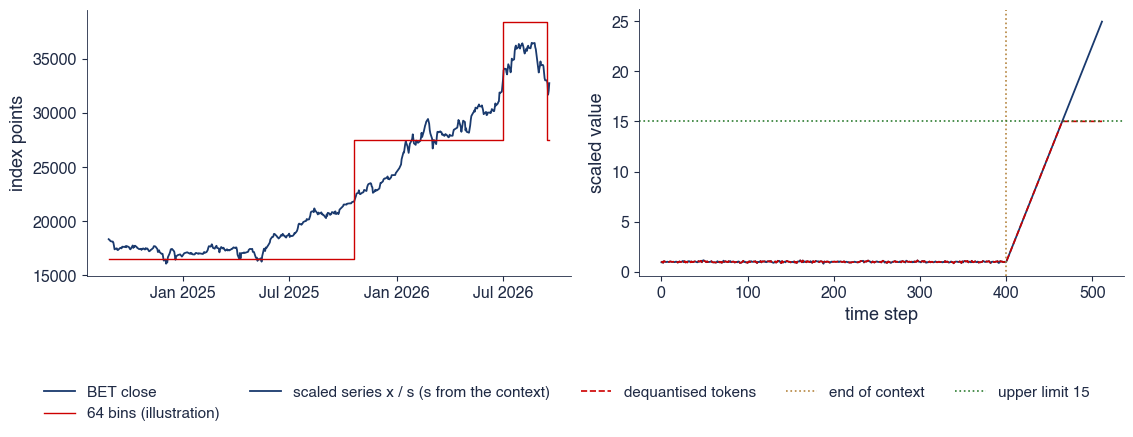

{'n': 512, 'scale': 23071.55791015625, 'width': 169.14631898941533, 'maxerr': 84.5208559097955, 'maxerr64': 5472.770369233618, 'first': '2024-08-27', 'last': '2026-09-18', 'jump_scaled': 24.94308154264557, 'jump_err': 0.3986308398040447, 'clip_share': 0.41964285714285715}


In [7]:
def fig_tokens(save_it=True, n=512):
    """The Chronos tokeniser on the last n daily closes of the BET: mean scaling, 4093 uniform bins on [-15, 15];
    a coarse 64-bin version to make the quantisation visible; the clipping of a series that leaves the range."""
    p = load_close('bet').iloc[-n:]
    ids, deq, s = chronos_tokenise(p.values)
    ids64, deq64, _ = chronos_tokenise(p.values, n_bins=64)
    width = 30 / (4093 - 1) * s
    rng = np.random.default_rng(SEED)
    ctx = 1 + 0.05 * rng.standard_normal(400)                                   # a context near 1, then the future
    fut = np.linspace(1, 25, 112)                                                # rises to 25 times that level
    _, _, sj = chronos_tokenise(ctx)
    centres = np.linspace(-15, 15, 4093)
    dj = sj * centres[np.clip(np.searchsorted((centres[1:] + centres[:-1]) / 2, fut / sj), 0, 4092)]
    jump = np.r_[ctx, fut]
    dj = np.r_[chronos_tokenise(ctx)[1], dj]
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.8))
    axs[0].plot(p.index, p.values, color=st.MainBlue, lw=1.3, label='BET close')
    axs[0].step(p.index, deq64, color=st.IDAred, lw=1.0, where='mid', label='64 bins (illustration)')
    axs[0].set_ylabel('index points')
    import matplotlib.dates as mdates
    axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axs[1].plot(np.arange(len(jump)), jump / sj, color=st.MainBlue, lw=1.3, label='scaled series x / s (s from the context)')
    axs[1].plot(np.arange(len(jump)), dj / sj, color=st.IDAred, lw=1.2, ls='--', label='dequantised tokens')
    axs[1].axvline(400, color=st.Amber, ls=':', lw=1.2, label='end of context')
    axs[1].axhline(15, color=st.Forest, ls=':', lw=1.2, label='upper limit 15')
    axs[1].set_ylabel('scaled value')
    axs[1].set_xlabel('time step')
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch13_tokens', save_it)
    return dict(n=n, scale=float(s), width=float(width), maxerr=float(np.max(np.abs(deq - p.values))),
                maxerr64=float(np.max(np.abs(deq64 - p.values))), first=str(p.index[0].date()), last=str(p.index[-1].date()),
                jump_scaled=float(jump[-1] / sj), jump_err=float(abs(dj[-1] - jump[-1]) / jump[-1]),
                clip_share=float(np.mean(fut / sj > 15)))


print(fig_tokens(save_it=False))

## 2. Four zero-shot forecasts

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

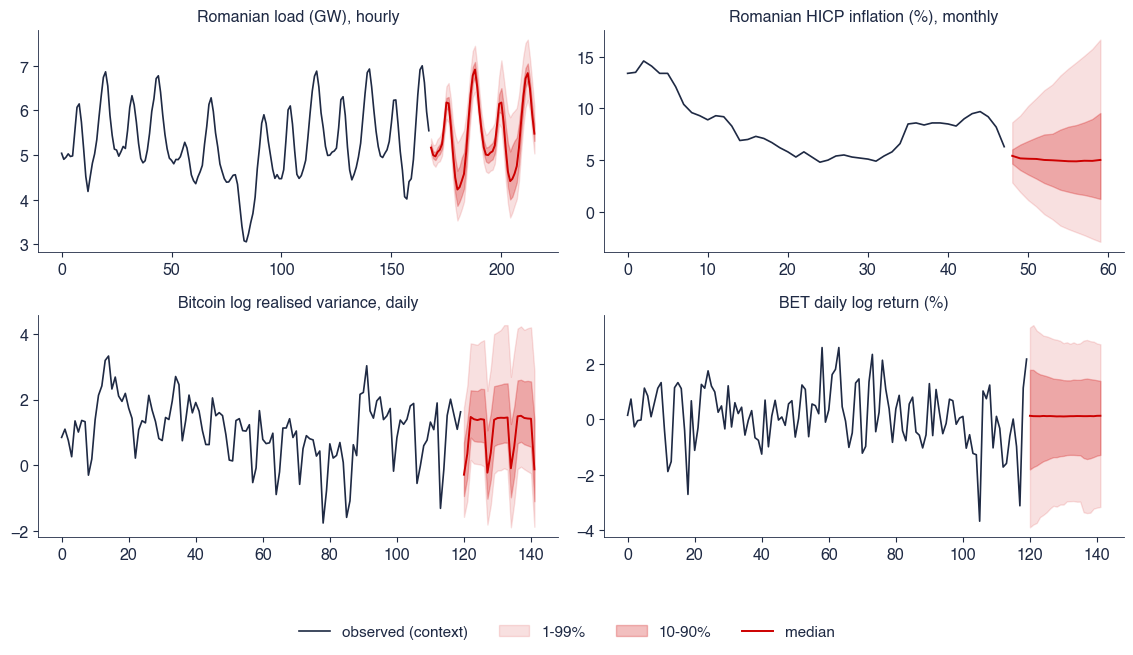

{'Romanian load (GW), hourly': {'q01': 4.992006301879883, 'q50': 5.166329860687256, 'q99': 5.371980667114258}, 'Romanian HICP inflation (%), monthly': {'q01': 2.8324880599975586, 'q50': 5.417795181274414, 'q99': 8.659948348999023}, 'Bitcoin log realised variance, daily': {'q01': -1.5611993074417114, 'q50': -0.2800583839416504, 'q99': 1.7614037990570068}, 'BET daily log return (%)': {'q01': -3.8962159156799316, 'q50': 0.12572172284126282, 'q99': 3.3080556392669678}}


In [8]:
def fig_zeroshot(save_it=True):
    """Four zero-shot Chronos-2 forecasts from the last origin of each data set: Romanian load (48 hours), Romanian
    inflation (12 months), Bitcoin log RV (22 days), daily BET returns (22 days; 1-99% band)."""
    if fm_load('Chronos-2') is None:
        return {}
    fig, axs = plt.subplots(2, 2, figsize=(11.5, 6.2))
    y = ro_load_hourly().values.ravel()
    sets = [(axs[0, 0], 'Romanian load (GW), hourly', y[-24 * 7:], y[-2048:], 48),
            (axs[0, 1], 'Romanian HICP inflation (%), monthly', eu_hicp()['RO'].values[-48:], eu_hicp()['RO'].values, 12),
            (axs[1, 0], 'Bitcoin log realised variance, daily', np.log(btc_rv().values[-120:]), np.log(btc_rv().values[-1024:]), 22),
            (axs[1, 1], 'BET daily log return (%)', log_returns('bet').values[-120:], log_returns('bet').values[-1024:], 22)]
    out = {}
    for ax, ttl, show, ctx, H in sets:
        Q = fm_forecast('Chronos-2', [ctx], H, [0.01, 0.1, 0.5, 0.9, 0.99])[0]
        n = len(show)
        ax.plot(np.arange(n), show, color=st.DarkText, lw=1.2, label='observed (context)')
        t = np.arange(n, n + H)
        ax.fill_between(t, Q[:, 0], Q[:, 4], color=st.IDAred, alpha=0.12, label='1-99%')
        ax.fill_between(t, Q[:, 1], Q[:, 3], color=st.IDAred, alpha=0.25, label='10-90%')
        ax.plot(t, Q[:, 2], color=st.IDAred, lw=1.4, label='median')
        ax.set_title(ttl, fontsize=11.5)
        out[ttl] = dict(q01=float(Q[0, 0]), q50=float(Q[0, 2]), q99=float(Q[0, 4]))
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    save('ats_ch13_zeroshot', save_it)
    return out


print(fig_zeroshot(save_it=False))

## 3. Romanian load: day-ahead comparison and covariates in context

- Forecast days from `LOAD_EVAL` (2025-01-01 on the slides).

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

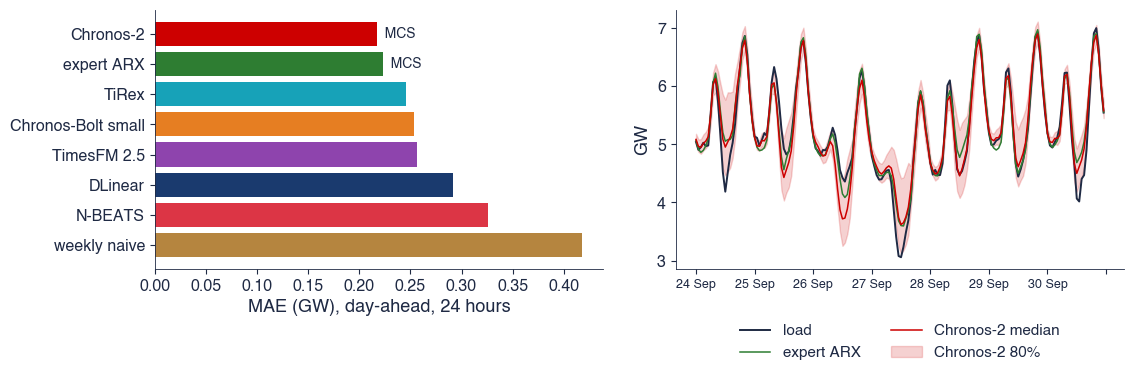

{'first': '2026-03-01', 'last': '2026-09-30', 'n_days': 214, 'mae': {'weekly naive': 0.4175154789719626, 'expert ARX': 0.22322568222748046, 'DLinear': 0.29208100463837633, 'N-BEATS': 0.32599662479638575, 'Chronos-Bolt small': 0.2538930894455806, 'Chronos-2': 0.21736588587307856, 'TimesFM 2.5': 0.2562893799732779, 'TiRex': 0.24610572379214746}, 'crps': {'weekly naive': 0.33016607827102806, 'expert ARX': 0.17961050746392135, 'Chronos-Bolt small': 0.2022931511423174, 'Chronos-2': 0.17279169296310531, 'TimesFM 2.5': 0.20449875094920306, 'TiRex': 0.19500657702845742}, 'cov80': {'weekly naive': 0.7683021806853583, 'expert ARX': 0.804322429906542, 'Chronos-Bolt small': 0.8160046728971962, 'Chronos-2': 0.7741433021806854, 'TimesFM 2.5': 0.8263239875389408, 'TiRex': 0.8084112149532711}, 'dm': {'weekly naive': {'t': 12.287699313561035, 'p': 1.3874594381059635e-26}, 'DLinear': {'t': 7.832495040561689, 'p': 2.2337166280975782e-13}, 'N-BEATS': {'t': 10.10485699686811, 'p': 7.316473891341605e-20}, '

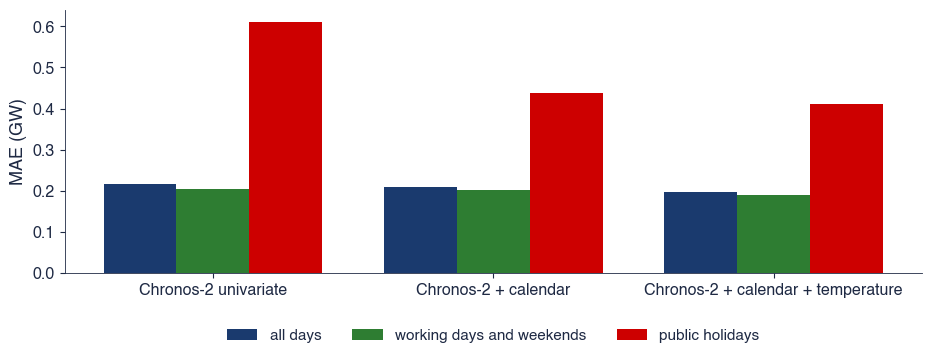

{'mae': {'univariate': {'all': 0.21736588587307856, 'hol': 0.6099504351502374, 'other': 0.20409007985887512, 'crps': 0.17279169296310531}, '+ calendar': {'all': 0.2086990411868348, 'hol': 0.43660044967560535, 'other': 0.20099223027175558, 'crps': 0.16532686971396712}, '+ calendar + temperature': {'all': 0.1978495242729365, 'hol': 0.41071960049583794, 'other': 0.19065101927989153, 'crps': 0.15501232504869422}}, 'n_hol': 7, 'dm_cal': {'t': -1.9309031212510104, 'p': 0.05482245300946148}, 'dm_tmp': {'t': -2.6267570534869935, 'p': 0.00924655479931157}}


In [9]:
def load_baselines(win=LOAD_WIN, res_win=LOAD_RES, first=None):
    """Day-ahead forecasts for day d1 with data up to day d1 - 1: the weekly naive and the expert ARX of Ziel and
    Weron (2018) for each hour (as in Chapter 1); quantiles = point forecast plus empirical quantiles of the last
    res_win errors at the same hour. Returns days, actuals, points and decile quantiles from `first`."""
    first = first or LOAD_EVAL
    Y = ro_load_hourly()
    days, A = Y.index, Y.values
    nD = len(days)
    dow = np.array([d.dayofweek for d in days])
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    P = {k: np.full((nD, 24), np.nan) for k in ('weekly naive', 'expert ARX')}
    for d1 in range(7, nD):
        P['weekly naive'][d1] = A[d1 - 7]
    mins, maxs, last = A.min(axis=1), A.max(axis=1), A[:, 23]
    for d1 in range(start - res_win - 1, nD):
        rows = np.arange(d1 - win, d1)
        for h in range(24):
            X = np.column_stack([np.ones(len(rows)), A[rows - 1, h], A[rows - 2, h], A[rows - 7, h], mins[rows - 1],
                                 maxs[rows - 1], last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6])
            b = np.linalg.lstsq(X, A[rows, h], rcond=None)[0]
            x = np.r_[1.0, A[d1 - 1, h], A[d1 - 2, h], A[d1 - 7, h], mins[d1 - 1], maxs[d1 - 1], last[d1 - 1],
                      dow[d1] == 0, dow[d1] == 5, dow[d1] == 6]
            P['expert ARX'][d1, h] = x @ b
    Q = {}
    for k in P:
        E = A - P[k]
        Q[k] = np.full((nD, 24, 9), np.nan)
        for d1 in range(start, nD):
            Q[k][d1] = P[k][d1][:, None] + np.nanquantile(E[d1 - res_win:d1], DECILES, axis=0).T
    return days[start:], A[start:], {k: v[start:] for k, v in P.items()}, {k: v[start:] for k, v in Q.items()}


def load_deep(first=None, L=336, refit_months=3, seed=SEED):
    """DLinear and N-BEATS (Chapter 12 architectures) trained on all hourly windows before each refit date (every
    refit_months months), inputs and targets divided by the mean of the input window; day-ahead point forecasts."""
    if not TORCH:
        return {}
    first = first or LOAD_EVAL
    Y = ro_load_hourly()
    days = Y.index
    y = Y.values.ravel()
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    out = {k: np.full((len(days) - start, 24), np.nan) for k in ('DLinear', 'N-BEATS')}
    refits = pd.date_range(first, days[-1], freq=f'{refit_months}MS')
    for i, r in enumerate(refits):
        d0 = int(np.searchsorted(days, r))
        d1 = int(np.searchsorted(days, refits[i + 1])) if i + 1 < len(refits) else len(days)
        ends = np.arange(L, d0 * 24 - 24 + 1, 6)                                    # window ends (hours), stride 6
        X = np.stack([y[e - L:e] for e in ends])
        Yt = np.stack([y[e:e + 24] for e in ends])
        sc = X.mean(axis=1, keepdims=True)
        Xo = np.stack([y[d * 24 - L:d * 24] for d in range(d0, d1)])
        so = Xo.mean(axis=1, keepdims=True)
        for k, net in (('DLinear', DLinear(L, 24)), ('N-BEATS', NBeats(L, 24))):
            set_seed(seed)
            m = fit_global(net, X / sc, Yt / sc, epochs=30, seed=seed)
            out[k][d0 - start:d1 - start] = predict_global(m, Xo / so) * so
    return out


def load_fm(first=None, ctx=LOAD_CTX, names=FMS):
    """Zero-shot day-ahead decile forecasts of the foundation models: context = the last ctx hours up to the end of
    day d1 - 1."""
    first = first or LOAD_EVAL
    Y = ro_load_hourly()
    days = Y.index
    y = Y.values.ravel()
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    C = [y[d * 24 - ctx:d * 24] for d in range(start, len(days))]
    out = {}
    for nm in names:
        Q = fm_cached(f'load_{first}_{ctx}', nm, C, 24, DECILES)
        if Q is not None:
            out[nm] = Q
    return out


def load_all():
    if 'load_all' in _MEM:
        return _MEM['load_all']
    days, A, P, Q = load_baselines()
    deep = load_deep()
    F = load_fm()
    for k, v in F.items():
        P[k] = v[:, :, 4]
        Q[k] = v
    P.update(deep)
    _MEM['load_all'] = (days, A, P, Q)
    return _MEM['load_all']


def fig_load(save_it=True):
    """Romanian day-ahead load, 2025-01-01 to LOAD_END: MAE and CRPS (deciles) by model, coverage of the 80% interval,
    DM tests against the expert ARX and the Model Confidence Set on daily MAE."""
    days, A, P, Q = load_all()
    names = [k for k in ['weekly naive', 'expert ARX', 'DLinear', 'N-BEATS'] + FMS if k in P]
    mae = {k: float(np.nanmean(np.abs(A - P[k]))) for k in names}
    daily = pd.DataFrame({k: np.abs(A - P[k]).mean(axis=1) for k in names}, index=days)
    crps = {k: float(np.nanmean(crps_q(A, Q[k], DECILES))) for k in names if k in Q}
    cov80 = {k: float(np.nanmean((A >= Q[k][:, :, 0]) & (A <= Q[k][:, :, 8]))) for k in names if k in Q}
    dm = {k: dm_test(daily[k] - daily['expert ARX'], 1) for k in names if k != 'expert ARX'}
    M = mcs(daily, alpha=0.10, block=7)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    order = sorted(names, key=lambda k: mae[k])
    base_col = {'weekly naive': st.Amber, 'expert ARX': st.Forest, 'DLinear': st.MainBlue, 'N-BEATS': st.Crimson}
    cols = [FM_COL.get(k, base_col.get(k, st.MainBlue)) for k in order]
    axs[0].barh(range(len(order)), [mae[k] for k in order], color=cols)
    for i, k in enumerate(order):
        axs[0].text(mae[k], i, ('  MCS' if k in M['set'] else ''), va='center', fontsize=10, color=st.DarkText)
    axs[0].set_yticks(range(len(order)))
    axs[0].set_yticklabels(order)
    axs[0].invert_yaxis()
    axs[0].set_xlabel('MAE (GW), day-ahead, 24 hours')
    wk = slice(len(days) - 7, len(days))
    t = np.arange(7 * 24)
    axs[1].plot(t, A[wk].ravel(), color=st.DarkText, lw=1.4, label='load')
    axs[1].plot(t, P['expert ARX'][wk].ravel(), color=st.Forest, lw=1.1, label='expert ARX')
    if 'Chronos-2' in Q:
        axs[1].plot(t, P['Chronos-2'][wk].ravel(), color=st.IDAred, lw=1.1, label='Chronos-2 median')
        axs[1].fill_between(t, Q['Chronos-2'][wk][:, :, 0].ravel(), Q['Chronos-2'][wk][:, :, 8].ravel(), color=st.IDAred,
                            alpha=0.18, label='Chronos-2 80%')
    axs[1].set_xticks(np.arange(0, 7 * 24 + 1, 24))
    axs[1].set_xticklabels([d.strftime('%d %b') for d in days[wk]] + [''], fontsize=9)
    axs[1].set_ylabel('GW')
    st.legend_outside_bottom(axs[1], ncol=2, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_load', save_it)
    return dict(first=str(days[0].date()), last=str(days[-1].date()), n_days=int(len(days)), mae=mae, crps=crps,
                cov80=cov80, dm={k: dict(t=v['hln'], p=v['p']) for k, v in dm.items()}, mcs=M['set'], mcs_p=M['p'])


def fig_covariates(save_it=True, first=None, ctx=LOAD_CTX):
    """Chronos-2 in-context covariates: univariate, + calendar (weekend and holiday flags of the context and of the
    forecast day), + calendar and Bucharest temperature (realised values for the forecast day: an oracle upper bound).
    MAE on holidays and on other days."""
    first = first or LOAD_EVAL
    Y = ro_load_hourly()
    days = Y.index
    y = Y.values.ravel()
    T = bucharest_temperature().reindex(days).interpolate(limit_direction='both').values.ravel()
    hol = set(ro_holidays(range(days[0].year, days[-1].year + 1)))
    dflag = np.array([(d in hol) for d in days], float)
    wflag = np.array([d.dayofweek >= 5 for d in days], float)
    hflag, wh = np.repeat(dflag, 24), np.repeat(wflag, 24)
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    D = range(start, len(days))
    C = [y[d * 24 - ctx:d * 24] for d in D]
    cal = [{'past': {'holiday': hflag[d * 24 - ctx:d * 24], 'weekend': wh[d * 24 - ctx:d * 24]},
            'future': {'holiday': hflag[d * 24:d * 24 + 24], 'weekend': wh[d * 24:d * 24 + 24]}} for d in D]
    tmp = [{'past': dict(c['past'], temp=T[d * 24 - ctx:d * 24]), 'future': dict(c['future'], temp=T[d * 24:d * 24 + 24])}
           for c, d in zip(cal, D)]
    A = Y.values[start:]
    res = {}
    for lab, cv in (('univariate', None), ('+ calendar', cal), ('+ calendar + temperature', tmp)):
        key = 'cov_' + lab.replace(' ', '').replace('+', 'p')
        Q = fm_cached(f'{key}_{first}_{ctx}', 'Chronos-2', C, 24, DECILES, covariates=cv)
        if Q is None:
            return {}
        res[lab] = Q
    isH = dflag[start:].astype(bool)
    mae = {k: dict(all=float(np.mean(np.abs(A - Q[:, :, 4]))), hol=float(np.mean(np.abs(A[isH] - Q[isH][:, :, 4]))),
                   other=float(np.mean(np.abs(A[~isH] - Q[~isH][:, :, 4]))),
                   crps=float(np.mean(crps_q(A, Q, DECILES)))) for k, Q in res.items()}
    daily = pd.DataFrame({k: np.abs(A - Q[:, :, 4]).mean(axis=1) for k, Q in res.items()})
    dm_cal = dm_test(daily['+ calendar'] - daily['univariate'], 1)
    dm_tmp = dm_test(daily['+ calendar + temperature'] - daily['+ calendar'], 1)
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    labs = list(res)
    x = np.arange(3)
    for j, (grp, nm) in enumerate((('all', 'all days'), ('other', 'working days and weekends'), ('hol', 'public holidays'))):
        ax.bar(x + (j - 1) * 0.26, [mae[k][grp] for k in labs], width=0.26, color=[st.MainBlue, st.Forest, st.IDAred][j], label=nm)
    ax.set_xticks(x)
    ax.set_xticklabels(['Chronos-2 ' + k for k in labs])
    ax.set_ylabel('MAE (GW)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_covariates', save_it)
    return dict(mae=mae, n_hol=int(isH.sum()), dm_cal=dict(t=dm_cal['hln'], p=dm_cal['p']),
                dm_tmp=dict(t=dm_tmp['hln'], p=dm_tmp['p']))


print(fig_load(save_it=False))
print(fig_covariates(save_it=False))

## 4. EU inflation: 27 countries, multiple testing

- Origins from `INFL['first']` (2012-01-01 on the slides).

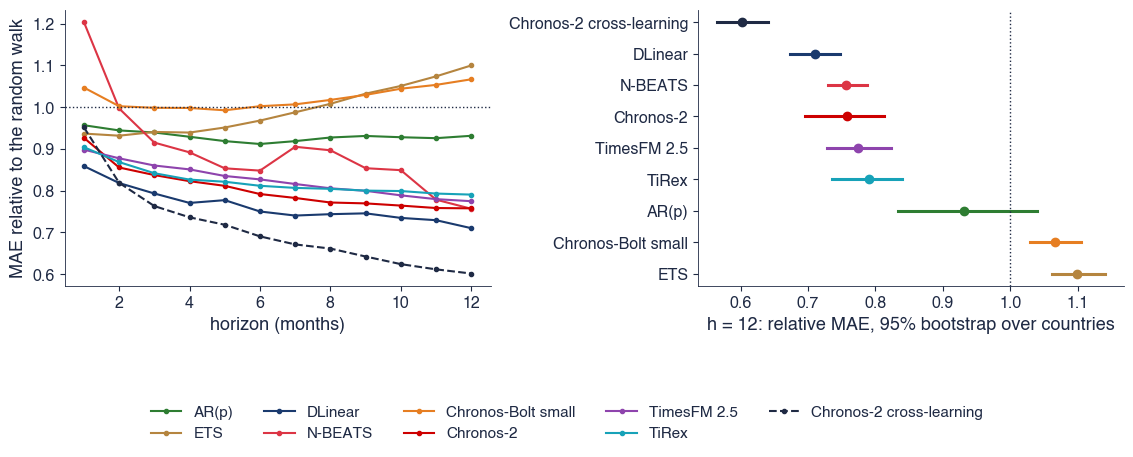

{'rel': {'AR(p)': {'h1': 0.9564863546583607, 'h6': 0.911543824517806, 'h12': 0.9311902005842857}, 'ETS': {'h1': 0.9365135880296931, 'h6': 0.9676399657083395, 'h12': 1.0997524644365466}, 'DLinear': {'h1': 0.8585476902139572, 'h6': 0.7498114681427357, 'h12': 0.7098228777139357}, 'N-BEATS': {'h1': 1.2036661940591473, 'h6': 0.8477637888888709, 'h12': 0.756287836523355}, 'Chronos-Bolt small': {'h1': 1.0467202473762243, 'h6': 1.0020753995482683, 'h12': 1.0665480163793057}, 'Chronos-2': {'h1': 0.9263283394274455, 'h6': 0.7916276908352686, 'h12': 0.7573530671269432}, 'TimesFM 2.5': {'h1': 0.8980034093880929, 'h6': 0.8266945513223732, 'h12': 0.7744948776038958}, 'TiRex': {'h1': 0.9038692657424681, 'h6': 0.8113905438502975, 'h12': 0.7902592437815433}, 'Chronos-2 cross-learning': {'h1': 0.951529739261979, 'h6': 0.6901699537369511, 'h12': 0.6011389910329284}}, 'ci': {'AR(p)': (0.8337709065840073, 1.04050145030893), 'ETS': (1.0621539495983097, 1.140189861811572), 'DLinear': (0.6730011477289642, 0.7

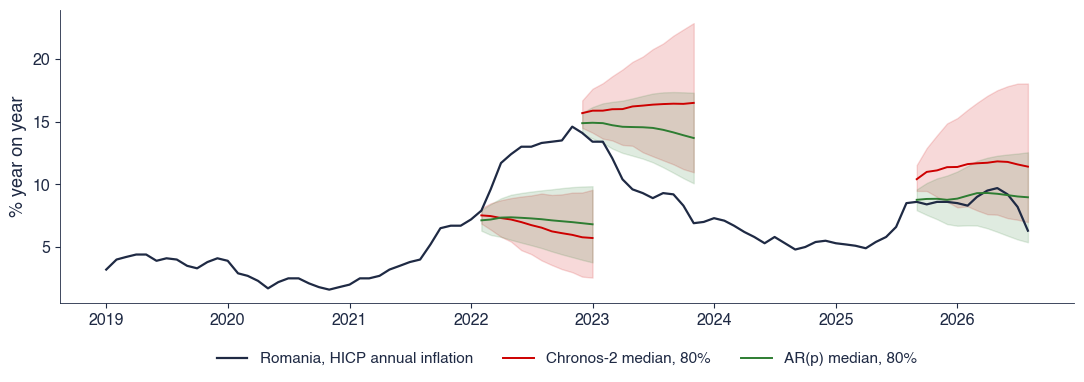

{'origins': ['2022-01-01', '2022-11-01', '2025-08-01'], 'fc': {'Chronos-2|0': {'med12': 5.717792510986328, 'lo12': 2.5601673126220703, 'hi12': 9.563682556152344, 'act12': 13.4}, 'AR(p)|0': {'med12': 6.81133270119923, 'lo12': 3.7729939037992595, 'hi12': 9.849671498599202, 'act12': 13.4}, 'Chronos-2|1': {'med12': 16.496116638183594, 'lo12': 10.962779998779297, 'hi12': 22.86039161682129, 'act12': 6.9}, 'AR(p)|1': {'med12': 13.69337027020889, 'lo12': 10.08056462629746, 'hi12': 17.306175914120317, 'act12': 6.9}, 'Chronos-2|2': {'med12': 11.41195297241211, 'lo12': 6.987669944763184, 'hi12': 18.041234970092773, 'act12': 6.3}, 'AR(p)|2': {'med12': 8.967245524767112, 'lo12': 5.380581584063497, 'hi12': 12.553909465470726, 'act12': 6.3}}, 'peak': 14.6, 'peak_date': '2022-11-01', 'last': 6.3, 'last_date': '2026-08-01'}


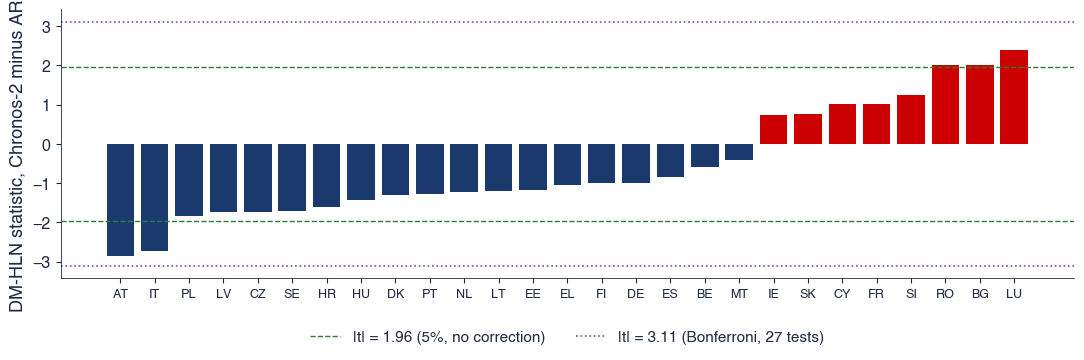

{'model': 'Chronos-2', 'h': 12, 'n': 27, 'rej': 3, 'rej_fm': 2, 'rej_ar': 1, 'rej_holm': 0, 'rej_bh': 0, 'neg': 19, 'ro_t': 2.011683435102303, 'ro_p': 0.05054667550440648, 'hc': 3.1130172634086897}


In [10]:
def infl_forecasts(first=None, H=None):
    """Rolling-origin forecasts of annual HICP inflation, h = 1..H, for the 27 EU countries: random walk, AR(p) by
    AIC (p <= 12), damped ETS, a global DLinear and N-BEATS (refit each January on all countries, look-back 36 months),
    and the foundation models (context: all observations since 2000; Chronos-2 also with cross-learning across the
    27 countries of the same origin). Returns origins, actual paths (n_orig x 27 x H) and forecasts {model: (point,
    deciles)}."""
    if 'infl' in _MEM:
        return _MEM['infl']
    first, H = first or INFL['first'], H or INFL['H']
    P = eu_hicp()
    dates = P.index
    Y = P.values
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    origins = list(range(o0, len(dates)))                       # origin = last observed month
    nO, nC = len(origins), len(EU27)
    act = np.full((nO, nC, H), np.nan)
    for i, o in enumerate(origins):
        for h in range(1, H + 1):
            if o + h < len(dates):
                act[i, :, h - 1] = Y[o + h]
    F = {}
    pt = np.repeat(Y[origins][:, :, None], H, axis=2)
    F['random walk'] = (pt, None)
    for nm, fn in (('AR(p)', lambda y: ar_forecast(y, H, DECILES)[:2]), ('ETS', lambda y: ets_forecast(y, H, DECILES))):
        cache = os.environ.get('ATS_FM_CACHE')
        path = os.path.join(cache, f'infl_{first}_{nm[:2]}.npy') if cache else None
        if path and os.path.exists(path):
            Z = np.load(path)
        else:
            Z = np.full((nO, nC, H, 10), np.nan)
            for i, o in enumerate(origins):
                for c in range(nC):
                    m, q = fn(Y[:o + 1, c])
                    Z[i, c, :, 0], Z[i, c, :, 1:] = m, q
            if path:
                np.save(path, Z)
        F[nm] = (Z[..., 0], Z[..., 1:])
    if TORCH:
        Lb = 36
        for nm, mk in (('DLinear', lambda: DLinear(Lb, H, k=13)), ('N-BEATS', lambda: NBeats(Lb, H, width=64))):
            Z = np.full((nO, nC, H), np.nan)
            for yr in sorted(set(dates[origins].year)):
                idx = [i for i, o in enumerate(origins) if dates[o].year == yr]
                o_first = origins[idx[0]]
                X, T_ = [], []
                for c in range(nC):
                    for e in range(Lb, o_first - H + 1):
                        X.append(Y[e - Lb:e, c])
                        T_.append(Y[e:e + H, c])
                X, T_ = np.array(X), np.array(T_)
                mu, sd = X.mean(axis=1, keepdims=True), X.std(axis=1, keepdims=True) + 0.5
                net = fit_global(mk(), (X - mu) / sd, (T_ - mu) / sd, epochs=60, seed=SEED)
                for i in idx:
                    o = origins[i]
                    Xo = Y[o + 1 - Lb:o + 1].T
                    m_, s_ = Xo.mean(axis=1, keepdims=True), Xo.std(axis=1, keepdims=True) + 0.5
                    Z[i] = predict_global(net, (Xo - m_) / s_) * s_ + m_
            F[nm] = (Z, None)
    ctxs = [Y[:o + 1, c] for o in origins for c in range(nC)]
    for nm in FMS:
        Q = fm_cached(f'infl_{first}_{H}', nm, ctxs, H, DECILES)
        if Q is not None:
            Q = Q.reshape(nO, nC, H, 9)
            F[nm] = (Q[..., 4], Q)
    if fm_load('Chronos-2') is not None:
        Q = fm_cached(f'infl_{first}_{H}_cross', 'Chronos-2', ctxs, H, DECILES, batch=nC, cross_learning=True)
        Q = Q.reshape(nO, nC, H, 9)
        F['Chronos-2 cross-learning'] = (Q[..., 4], Q)
    _MEM['infl'] = (dates, origins, act, F)
    return _MEM['infl']


def fig_inflation(save_it=True):
    """MAE relative to the random walk by horizon (geometric mean over countries of the country-level ratios), with
    95% bootstrap intervals over countries at h = 12; CRPS of the probabilistic models relative to AR(p)."""
    dates, origins, act, F = infl_forecasts()
    H = act.shape[2]
    rw = F['random walk'][0]
    names = [k for k in ['AR(p)', 'ETS', 'DLinear', 'N-BEATS'] + FMS + ['Chronos-2 cross-learning'] if k in F]
    rel = {}
    for k in names:
        e, e0 = np.abs(act - F[k][0]), np.abs(act - rw)
        r = np.nanmean(e, axis=0) / np.nanmean(e0, axis=0)                     # countries x H
        rel[k] = [gmean(r[:, h]) for h in range(H)]
    rng = np.random.default_rng(SEED)
    ci = {}
    for k in names:
        e, e0 = np.abs(act[:, :, -1] - F[k][0][:, :, -1]), np.abs(act[:, :, -1] - rw[:, :, -1])
        r = np.nanmean(e, axis=0) / np.nanmean(e0, axis=0)
        b = [gmean(r[rng.integers(0, len(r), len(r))]) for _ in range(2000)]
        ci[k] = (float(np.quantile(b, 0.025)), float(np.quantile(b, 0.975)))
    crps_rel = {}
    for k in names:
        if F[k][1] is None:
            continue
        c = np.nanmean(crps_q(act, F[k][1], DECILES), axis=(0, 2)) / np.nanmean(crps_q(act, F['AR(p)'][1], DECILES), axis=(0, 2))
        crps_rel[k] = gmean(c)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    hh = np.arange(1, H + 1)
    for k in names:
        c = FM_COL.get(k, {'AR(p)': st.Forest, 'ETS': st.Amber, 'DLinear': st.MainBlue, 'N-BEATS': st.Crimson,
                           'Chronos-2 cross-learning': st.DarkText}.get(k, st.MainBlue))
        ls = '--' if k == 'Chronos-2 cross-learning' else '-'
        axs[0].plot(hh, rel[k], color=c, lw=1.5, ls=ls, marker='o', ms=3, label=k)
    axs[0].axhline(1, color=st.DarkText, ls=':', lw=1)
    axs[0].set_xlabel('horizon (months)')
    axs[0].set_ylabel('MAE relative to the random walk')
    order = sorted(names, key=lambda k: rel[k][-1])
    for i, k in enumerate(order):
        c = FM_COL.get(k, {'AR(p)': st.Forest, 'ETS': st.Amber, 'DLinear': st.MainBlue, 'N-BEATS': st.Crimson,
                           'Chronos-2 cross-learning': st.DarkText}.get(k, st.MainBlue))
        axs[1].plot(ci[k], [i, i], color=c, lw=2.2)
        axs[1].plot(rel[k][-1], i, 'o', color=c)
    axs[1].set_yticks(range(len(order)))
    axs[1].set_yticklabels(order)
    axs[1].invert_yaxis()
    axs[1].axvline(1, color=st.DarkText, ls=':', lw=1)
    axs[1].set_xlabel('h = 12: relative MAE, 95% bootstrap over countries')
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch13_inflation', save_it)
    return dict(rel={k: dict(h1=v[0], h6=v[5], h12=v[-1]) for k, v in rel.items()}, ci=ci, crps_rel=crps_rel,
                first=str(dates[origins[0]].date()), last=str(dates[origins[-1] - H].date()), n_orig=len(origins),
                end=str(dates[-1].date()))


def fig_ro_inflation(save_it=True):
    """Romanian HICP inflation: Chronos-2 and AR(p) 12-month forecasts with 80% bands from three origins (before the
    2022 surge, at its peak, and the latest origin with a full year of outcomes)."""
    dates, origins, act, F = infl_forecasts()
    P = eu_hicp()['RO']
    c = EU27.index('RO')
    oo = [pd.Timestamp('2021-06-01'), pd.Timestamp('2022-11-01'), dates[origins[-1]] - pd.DateOffset(months=12)]
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(P.loc['2019':].index, P.loc['2019':].values, color=st.DarkText, lw=1.6, label='Romania, HICP annual inflation')
    out, used = {}, []
    for j, o in enumerate(oo):
        i = int(np.clip(np.searchsorted(dates[origins], o), 0, len(origins) - 1))
        od = dates[origins[i]]
        used.append(str(od.date()))
        fx = pd.date_range(od + pd.DateOffset(months=1), periods=12, freq='MS')
        for k, col in (('Chronos-2', st.IDAred), ('AR(p)', st.Forest)):
            if k not in F:
                continue
            q = F[k][1][i, c]
            ax.plot(fx, q[:, 4], color=col, lw=1.4, label=f'{k} median, 80%' if j == 0 else None)
            ax.fill_between(fx, q[:, 0], q[:, 8], color=col, alpha=0.15)
            out[f'{k}|{j}'] = dict(med12=float(q[-1, 4]), lo12=float(q[-1, 0]), hi12=float(q[-1, 8]),
                                   act12=float(act[i, c, -1]))
    ax.set_ylabel('% year on year')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    plt.tight_layout()
    save('ats_ch13_ro_inflation', save_it)
    return dict(origins=used, fc=out, peak=float(P.loc['2021':'2024'].max()),
                peak_date=str(P.loc['2021':'2024'].idxmax().date()), last=float(P.iloc[-1]), last_date=str(P.index[-1].date()))


def fig_multiple(save_it=True, model='Chronos-2', h=12):
    """Country-level DM tests (HLN, HAC with h - 1 lags) of the h-step absolute errors of a foundation model against
    AR(p): the distribution of the 27 p-values and the number of rejections at 5% without correction, with Holm and
    with Benjamini-Hochberg."""
    dates, origins, act, F = infl_forecasts()
    p, t = [], []
    for c in range(len(EU27)):
        d = np.abs(act[:, c, h - 1] - F[model][0][:, c, h - 1]) - np.abs(act[:, c, h - 1] - F['AR(p)'][0][:, c, h - 1])
        r = dm_test(d[~np.isnan(d)], h)
        p.append(r['p'])
        t.append(r['hln'])
    p, t = np.array(p), np.array(t)
    ph, pb = holm(p), bh(p)
    fig, ax = plt.subplots(figsize=(11, 3.8))
    o = np.argsort(t)
    cols = [st.MainBlue if t[i] < 0 else st.IDAred for i in o]
    ax.bar(range(len(o)), t[o], color=cols)
    ax.set_xticks(range(len(o)))
    ax.set_xticklabels([EU27[i] for i in o], fontsize=9)
    crit = 1.96
    ax.axhline(-crit, color=st.Forest, ls='--', lw=1, label='|t| = 1.96 (5%, no correction)')
    ax.axhline(crit, color=st.Forest, ls='--', lw=1)
    from scipy import stats as _s
    hc = _s.norm.ppf(1 - 0.025 / len(EU27))
    ax.axhline(-hc, color=st.Purple, ls=':', lw=1.2, label=f'|t| = {hc:.2f} (Bonferroni, 27 tests)')
    ax.axhline(hc, color=st.Purple, ls=':', lw=1.2)
    ax.set_ylabel(f'DM-HLN statistic, {model} minus AR(p)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    plt.tight_layout()
    save('ats_ch13_multiple', save_it)
    return dict(model=model, h=h, n=len(p), rej=int((p < 0.05).sum()), rej_fm=int(((p < 0.05) & (t < 0)).sum()),
                rej_ar=int(((p < 0.05) & (t > 0)).sum()), rej_holm=int((ph < 0.05).sum()), rej_bh=int((pb < 0.05).sum()),
                neg=int((t < 0).sum()), ro_t=float(t[EU27.index('RO')]), ro_p=float(p[EU27.index('RO')]), hc=float(hc))


print(fig_inflation(save_it=False))
print(fig_ro_inflation(save_it=False))
print(fig_multiple(save_it=False))

## 5. Realised variance against HAR; windows before and after the releases

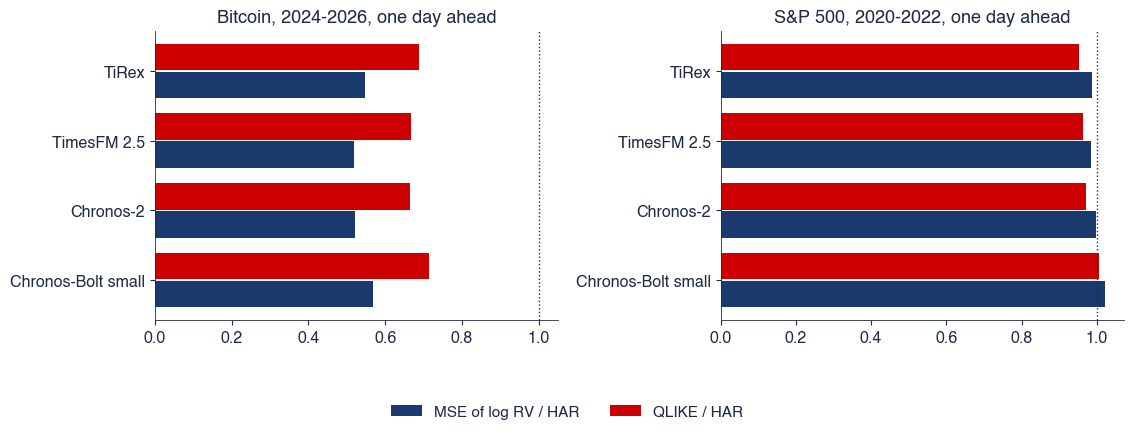

{'btc': {'mse': {'HAR': 0.5789805364619128, 'Chronos-Bolt small': 0.32967999038689266, 'Chronos-2': 0.3024740525291996, 'TimesFM 2.5': 0.30108980962953896, 'TiRex': 0.31689420092072096}, 'qlike': {'HAR': 0.29297711528039816, 'Chronos-Bolt small': 0.20952781915683838, 'Chronos-2': 0.1947074494034245, 'TimesFM 2.5': 0.1951241957956559, 'TiRex': 0.2017571665905569}, 'mcs': ['Chronos-2', 'TimesFM 2.5'], 'dm': {'Chronos-Bolt small': {'t': -6.3020911852655335, 'p': 4.744194803155948e-10}, 'Chronos-2': {'t': -7.340974941885785, 'p': 5.025161176582361e-13}, 'TimesFM 2.5': {'t': -6.778012787794203, 'p': 2.2984967277054904e-11}, 'TiRex': {'t': -6.929501658793734, 'p': 8.428971058223535e-12}}, 'first': '2024-06-03', 'last': '2026-09-18', 'n': 838, 'win': {'pre': {'HAR': 1.0, 'Chronos-Bolt small': 0.6783462429223043, 'Chronos-2': 0.6530278567509313, 'TimesFM 2.5': 0.6504970517063847, 'TiRex': 0.6665784492580736}, 'pre_n': 175, 'post': {'HAR': 1.0, 'Chronos-Bolt small': 0.6962980254372496, 'Chronos

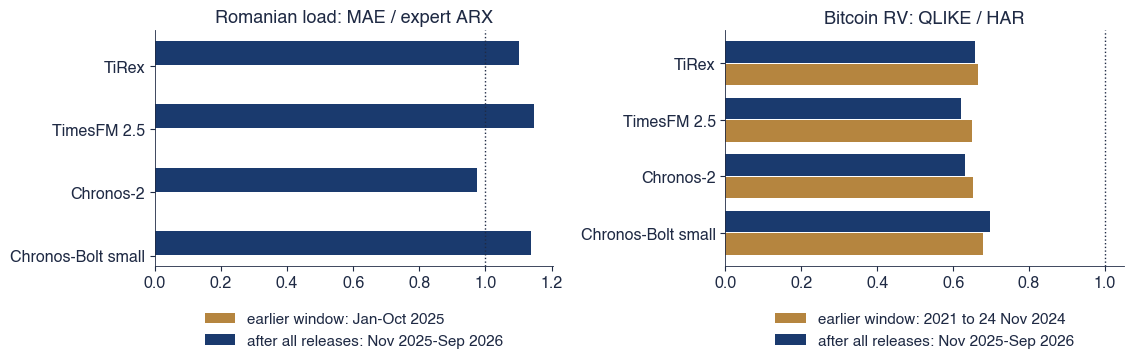

{'load': {'Chronos-Bolt small': [nan, 1.1373829700600855], 'Chronos-2': [nan, 0.97374945259018], 'TimesFM 2.5': [nan, 1.1481178035424415], 'TiRex': [nan, 1.102497353065992]}, 'btc': {'Chronos-Bolt small': [0.6783462429223043, 0.6962980254372496], 'Chronos-2': [0.6530278567509313, 0.6305381385333609], 'TimesFM 2.5': [0.6504970517063847, 0.6211748080217784], 'TiRex': [0.6665784492580736, 0.6581065230545287]}, 'n_load': [0, 214], 'n_btc': [175, 322]}


In [11]:
def rv_forecasts(series='btc', first=None, ctx=1024, win=1000):
    """One-day-ahead forecasts of log realised variance: HAR on a rolling window of `win` days and the foundation
    models (context: the last ctx days of log RV). Variance forecasts: exp(median + s^2/2), s from the 10-90% spread
    (HAR: the residual s.d.). Returns dates, rv, {model: (log median, variance forecast, deciles of log RV)}."""
    key = f'rv_{series}'
    if key in _MEM:
        return _MEM[key]
    rv = btc_rv() if series == 'btc' else spx_rv()
    first = first or RV_FIRST[series]
    x = np.log(rv.values)
    dates = rv.index
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    idx = np.arange(o0, len(x))
    out = {}
    med, var = np.empty(len(idx)), np.empty(len(idx))
    for j, t in enumerate(idx):
        f, s = har_forecast(x[t - win:t], 1)
        med[j], var[j] = f, np.exp(f + s ** 2 / 2)
    out['HAR'] = (med, var, None)
    C = [x[t - ctx:t] for t in idx]
    for nm in FMS:
        Q = fm_cached(f'{key}_{first}_{ctx}', nm, C, 1, DECILES)
        if Q is None:
            continue
        q = Q[:, 0, :]
        s = (q[:, 8] - q[:, 0]) / (2 * 1.2816)
        out[nm] = (q[:, 4], np.exp(q[:, 4] + s ** 2 / 2), q)
    _MEM[key] = (dates[idx], rv.values[idx], x[idx], out)
    return _MEM[key]


def fig_rv(save_it=True):
    """Bitcoin (Binance, 2021-2026) and S&P 500 (Oxford-Man, 2010-2022): MSE of log RV and QLIKE relative to HAR,
    MCS on QLIKE; for Bitcoin, the ratio before the first release and after the last release of the models."""
    res = {}
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    for ax, ser, lab in ((axs[0], 'btc', 'Bitcoin'), (axs[1], 'spx', 'S&P 500')):
        dates, rv, x, F = rv_forecasts(ser)
        names = list(F)
        mse = {k: float(np.mean((x - F[k][0]) ** 2)) for k in names}
        ql = {k: float(np.mean(qlike(rv, F[k][1]))) for k in names}
        L = pd.DataFrame({k: qlike(rv, F[k][1]) for k in names}, index=dates)
        M = mcs(L, alpha=0.10, block=10)
        dm = {k: dm_test(L[k] - L['HAR'], 1) for k in names if k != 'HAR'}
        win = {}
        if ser == 'btc':
            for w, (a, b) in (('pre', (dates[0], PRE_END)), ('post', (POST_START, dates[-1]))):
                m = (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
                win[w] = {k: float(np.mean(qlike(rv[m], F[k][1][m])) / np.mean(qlike(rv[m], F['HAR'][1][m]))) for k in names}
                win[w + '_n'] = int(m.sum())
        res[ser] = dict(mse=mse, qlike=ql, mcs=M['set'], dm={k: dict(t=v['hln'], p=v['p']) for k, v in dm.items()},
                        first=str(dates[0].date()), last=str(dates[-1].date()), n=int(len(dates)), win=win)
        ks = [k for k in names if k != 'HAR']
        r1 = [mse[k] / mse['HAR'] for k in ks]
        r2 = [ql[k] / ql['HAR'] for k in ks]
        y = np.arange(len(ks))
        ax.barh(y - 0.2, r1, height=0.38, color=st.MainBlue, label='MSE of log RV / HAR')
        ax.barh(y + 0.2, r2, height=0.38, color=st.IDAred, label='QLIKE / HAR')
        ax.set_yticks(y)
        ax.set_yticklabels(ks)
        ax.axvline(1, color=st.DarkText, ls=':', lw=1)
        ax.set_title(f'{lab}, {dates[0].year}-{dates[-1].year}, one day ahead')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch13_rv', save_it)
    return res


def fig_contamination(save_it=True):
    """Relative accuracy of each foundation model in an earlier window and after the last release (from 1 November
    2025): Romanian load (MAE / expert ARX; earlier window January-October 2025, before the release of Chronos-2 and
    TimesFM 2.5) and Bitcoin RV (QLIKE / HAR; earlier window 2021 to 24 November 2024, before every release)."""
    days, A, P, Q = load_all()
    m1 = (days >= pd.Timestamp('2025-01-01')) & (days <= pd.Timestamp('2025-10-31'))
    m2 = days >= pd.Timestamp(POST_START)
    ld = {}
    for k in FMS:
        if k in P:
            ld[k] = [float(np.mean(np.abs(A[m] - P[k][m])) / np.mean(np.abs(A[m] - P['expert ARX'][m]))) for m in (m1, m2)]
    dates, rv, x, F = rv_forecasts('btc')
    b1 = dates <= pd.Timestamp(PRE_END)
    b2 = dates >= pd.Timestamp(POST_START)
    bt = {}
    for k in FMS:
        if k in F:
            bt[k] = [float(np.mean(qlike(rv[m], F[k][1][m])) / np.mean(qlike(rv[m], F['HAR'][1][m]))) for m in (b1, b2)]
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.9))
    for ax, R, ttl, labs in ((axs[0], ld, 'Romanian load: MAE / expert ARX', ('Jan-Oct 2025', 'Nov 2025-Sep 2026')),
                              (axs[1], bt, 'Bitcoin RV: QLIKE / HAR', ('2021 to 24 Nov 2024', 'Nov 2025-Sep 2026'))):
        ks = list(R)
        y = np.arange(len(ks))
        ax.barh(y - 0.2, [R[k][0] for k in ks], height=0.38, color=st.Amber, label='earlier window: ' + labs[0])
        ax.barh(y + 0.2, [R[k][1] for k in ks], height=0.38, color=st.MainBlue, label='after all releases: ' + labs[1])
        ax.set_yticks(y)
        ax.set_yticklabels(ks)
        ax.axvline(1, color=st.DarkText, ls=':', lw=1)
        ax.set_title(ttl)
        st.legend_outside_bottom(ax, ncol=1, y=-0.14)
    plt.tight_layout()
    save('ats_ch13_contamination', save_it)
    return dict(load=ld, btc=bt, n_load=[int(m1.sum()), int(m2.sum())], n_btc=[int(b1.sum()), int(b2.sum())])


print(fig_rv(save_it=False))
print(fig_contamination(save_it=False))

## 6. Size against accuracy

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

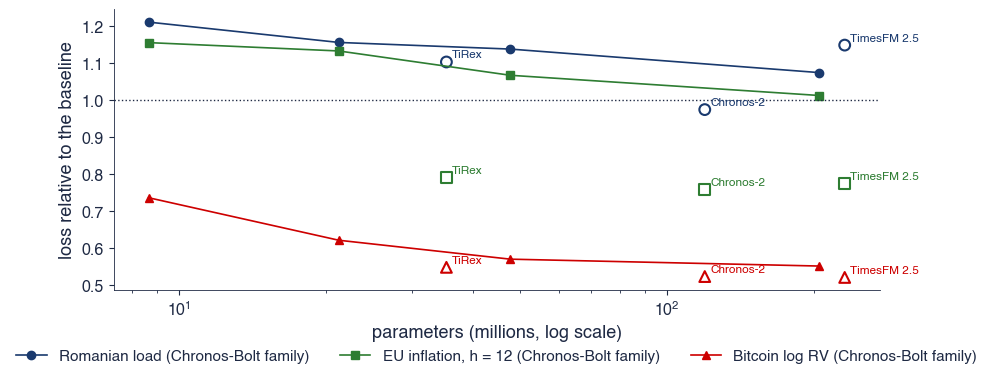

{'params': {'Chronos-Bolt tiny': 8.652672, 'Chronos-Bolt mini': 21.236096, 'Chronos-Bolt small': 47.718016, 'Chronos-Bolt base': 205.292928, 'Chronos-2': 119.477664, 'TimesFM 2.5': 231.28928, 'TiRex': 35.2912}, 'load': {'Chronos-Bolt tiny': 1.2102937976320034, 'Chronos-Bolt mini': 1.155340870517107, 'Chronos-Bolt small': 1.1373829700600855, 'Chronos-Bolt base': 1.0737443650659908, 'Chronos-2': 0.97374945259018, 'TimesFM 2.5': 1.1481178035424415, 'TiRex': 1.102497353065992}, 'infl': {'Chronos-Bolt tiny': 1.1548555822650628, 'Chronos-Bolt mini': 1.1322784328578979, 'Chronos-Bolt small': 1.0665480163793057, 'Chronos-Bolt base': 1.0118711361287125, 'Chronos-2': 0.7573530671269432, 'TimesFM 2.5': 0.7744948776038958, 'TiRex': 0.7902592437815433}, 'rv': {'Chronos-Bolt tiny': 0.7355314427869307, 'Chronos-Bolt mini': 0.6205602949817852, 'Chronos-Bolt small': 0.5694146342147031, 'Chronos-Bolt base': 0.5508035929071324, 'Chronos-2': 0.5224252517668136, 'TimesFM 2.5': 0.5200344237294505, 'TiRex': 

In [12]:
def rv_forecasts_extra(series, names, ctx=1024):
    """Log-RV medians of additional models (the scaling chart), same design as rv_forecasts."""
    dates, rv, x, F = rv_forecasts(series)
    full = np.log(btc_rv().values if series == 'btc' else spx_rv().values)
    first = RV_FIRST[series]
    alld = (btc_rv() if series == 'btc' else spx_rv()).index
    o0 = int(np.searchsorted(alld, pd.Timestamp(first)))
    C = [full[t - ctx:t] for t in range(o0, len(full))]
    out = {}
    for nm in names:
        Q = fm_cached(f'rv_{series}_{first}_{ctx}', nm, C, 1, DECILES)
        if Q is not None:
            out[nm] = Q[:, 0, 4]
    return out


def fig_scaling(save_it=True):
    """Accuracy against the number of parameters: the Chronos-Bolt family (tiny, mini, small, base), Chronos-2,
    TimesFM 2.5 and TiRex on three tasks: Romanian load (MAE / expert ARX, 2025-2026), EU inflation (MAE / random walk,
    h = 12) and Bitcoin RV (MSE of log RV / HAR)."""
    names = ['Chronos-Bolt tiny', 'Chronos-Bolt mini', 'Chronos-Bolt small', 'Chronos-Bolt base', 'Chronos-2',
             'TimesFM 2.5', 'TiRex']
    names = [k for k in names if fm_load(k) is not None]
    par = {k: fm_params(k) for k in names}
    days, A, P, Q = load_all()
    extra = load_fm(names=[k for k in names if k not in P])
    PP = dict(P, **{k: v[:, :, 4] for k, v in extra.items()})
    base = np.mean(np.abs(A - P['expert ARX']))
    r_load = {k: float(np.mean(np.abs(A - PP[k])) / base) for k in names}
    dates, origins, act, F = infl_forecasts()
    Y = eu_hicp().values
    ctxs = [Y[:o + 1, c] for o in origins for c in range(len(EU27))]
    rw = np.abs(act[:, :, -1] - F['random walk'][0][:, :, -1])
    r_inf = {}
    for k in names:
        f = F[k][0] if k in F else fm_cached(f'infl_{INFL["first"]}_{INFL["H"]}', k, ctxs, act.shape[2], DECILES).reshape(
            len(origins), len(EU27), act.shape[2], 9)[..., 4]
        r = np.nanmean(np.abs(act[:, :, -1] - f[:, :, -1]), axis=0) / np.nanmean(rw, axis=0)
        r_inf[k] = gmean(r)
    d2, rv, x, FR = rv_forecasts('btc')
    rv_all = rv_forecasts_extra('btc', [k for k in names if k not in FR])
    har = np.mean((x - FR['HAR'][0]) ** 2)
    r_rv = {k: float(np.mean((x - (FR[k][0] if k in FR else rv_all[k])) ** 2) / har) for k in names}
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for R, mk, lab, col in ((r_load, 'o', 'Romanian load', st.MainBlue), (r_inf, 's', 'EU inflation, h = 12', st.Forest),
                            (r_rv, '^', 'Bitcoin log RV', st.IDAred)):
        bolt = [k for k in names if k.startswith('Chronos-Bolt')]
        ax.plot([par[k] for k in bolt], [R[k] for k in bolt], color=col, lw=1.2, marker=mk, label=lab + ' (Chronos-Bolt family)')
        oth = [k for k in names if not k.startswith('Chronos-Bolt')]
        ax.scatter([par[k] for k in oth], [R[k] for k in oth], color=col, marker=mk, s=60, facecolors='none', linewidths=1.5)
        for k in oth:
            ax.annotate(k, (par[k], R[k]), textcoords='offset points', xytext=(4, 3), fontsize=8.5, color=col)
    ax.set_xscale('log')
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_xlabel('parameters (millions, log scale)')
    ax.set_ylabel('loss relative to the baseline')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_scaling', save_it)
    return dict(params=par, load=r_load, infl=r_inf, rv=r_rv)


print(fig_scaling(save_it=False))

## 7. Split conformal and CQR

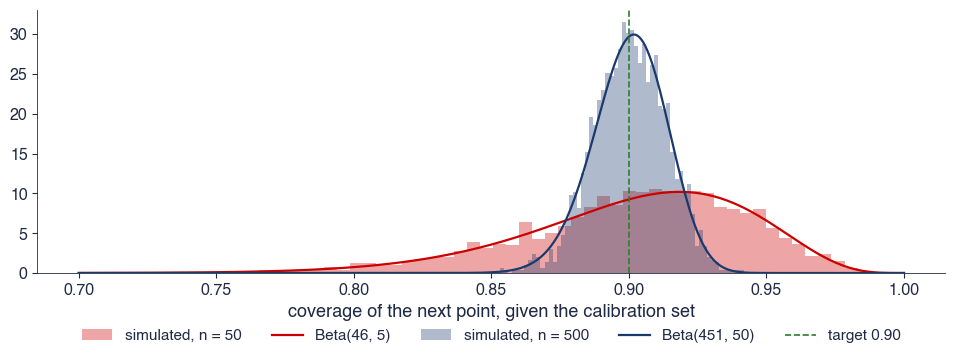

{'n50': {'mean': 0.901657663538239, 'sd': 0.04069434508768701, 'theory_mean': 0.9019607843137255, 'theory_sd': 0.04123747545849869, 'p_below': 0.4325, 'p_below88': 0.2565, 'q05': 0.8265257655127686, 'k': 46}, 'n500': {'mean': 0.9003831361743923, 'sd': 0.013164869805353448, 'theory_mean': 0.9001996007984032, 'theory_sd': 0.013377768881268464, 'p_below': 0.4845, 'p_below88': 0.064, 'q05': 0.878916428677106, 'k': 451}, 'reps': 2000}


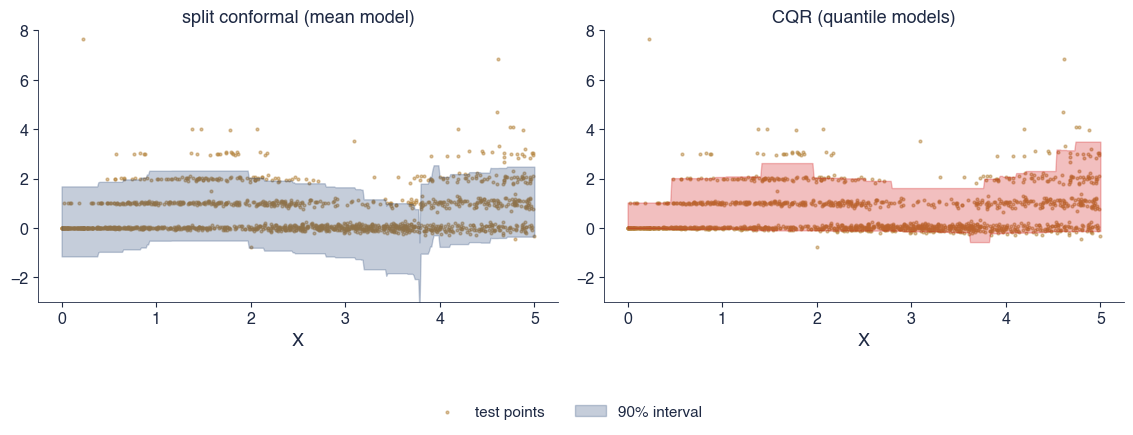

{'split': {'cov': 0.9176, 'width': 2.837079699029388, 'bins': [0.962, 0.9064039408866995, 0.9099804305283757, 0.8963782696177063, 0.913312693498452]}, 'cqr': {'cov': 0.915, 'width': 2.204128691952001, 'bins': [0.967, 0.8945812807881773, 0.8923679060665362, 0.9175050301810865, 0.9040247678018576]}, 'raw': {'cov': 0.8826, 'width': 2.1664872549279086}}


In [13]:
def fig_split_coverage(save_it=True, reps=4000, alpha=0.1, seed=SEED):
    """Coverage of split conformal conditional on the calibration set: with n calibration scores the coverage of the
    next point is F(q_hat), distributed Beta(k, n + 1 - k), k = ceil((n + 1)(1 - alpha)) (continuous scores).
    Simulation: |N(0, 1)| scores; n = 50 and 500."""
    from scipy import stats as _s
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    out = {}
    for n, col in ((50, st.IDAred), (500, st.MainBlue)):
        cov = []
        for _ in range(reps):
            sc = np.abs(rng.standard_normal(n))
            q = conformal_quantile(sc, alpha)
            cov.append(2 * _s.norm.cdf(q) - 1)
        cov = np.array(cov)
        k = int(np.ceil((n + 1) * (1 - alpha)))
        ax.hist(cov, bins=60, density=True, color=col, alpha=0.35, label=f'simulated, n = {n}')
        g = np.linspace(0.7, 1, 400)
        ax.plot(g, _s.beta.pdf(g, k, n + 1 - k), color=col, lw=1.6, label=f'Beta({k}, {n + 1 - k})')
        out[n] = dict(mean=float(cov.mean()), sd=float(cov.std()), theory_mean=k / (n + 1),
                      theory_sd=float(_s.beta.std(k, n + 1 - k)), p_below=float((cov < 1 - alpha).mean()),
                      p_below88=float((cov < 0.88).mean()), q05=float(np.quantile(cov, 0.05)), k=k)
    ax.axvline(1 - alpha, color=st.Forest, ls='--', lw=1.2, label='target 0.90')
    ax.set_xlabel('coverage of the next point, given the calibration set')
    st.legend_outside_bottom(ax, ncol=5, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_split_coverage', save_it)
    return dict(n50=out[50], n500=out[500], reps=reps)


def cqr_data(n, rng):
    """The synthetic design of Romano, Patterson and Candes (2019, Figure 1):
    Y = Pois(sin^2(X) + 0.1) + 0.03 X e1 + 25 1{U < 0.01} e2, X ~ U[0, 5], e1, e2 ~ N(0, 1)."""
    X = rng.uniform(0, 5, n)
    Y = (rng.poisson(np.sin(X) ** 2 + 0.1) + 0.03 * X * rng.standard_normal(n)
         + 25 * (rng.uniform(size=n) < 0.01) * rng.standard_normal(n))
    return X, Y


def fig_cqr(save_it=True, n=2000, n_test=5000, alpha=0.1, seed=SEED):
    """Split conformal with a conditional-mean model against CQR with quantile models (gradient boosting with the
    pinball loss), 1000 training and 1000 calibration points; coverage and width overall and by X."""
    from sklearn.ensemble import GradientBoostingRegressor as GBR
    rng = np.random.default_rng(seed)
    X, Y = cqr_data(n, rng)
    Xt, Yt = cqr_data(n_test, rng)
    tr, ca = slice(0, n // 2), slice(n // 2, n)
    kw = dict(n_estimators=150, max_depth=2, learning_rate=0.05, min_samples_leaf=50, random_state=seed)
    mean = GBR(loss='squared_error', **kw).fit(X[tr, None], Y[tr])
    lo = GBR(loss='quantile', alpha=alpha / 2, **kw).fit(X[tr, None], Y[tr])
    hi = GBR(loss='quantile', alpha=1 - alpha / 2, **kw).fit(X[tr, None], Y[tr])
    g = np.linspace(0, 5, 400)
    s_lo, s_hi = split_conformal(Y[ca], mean.predict(X[ca, None]), mean.predict(Xt[:, None]), alpha)
    c_lo, c_hi = cqr(Y[ca], lo.predict(X[ca, None]), hi.predict(X[ca, None]), lo.predict(Xt[:, None]), hi.predict(Xt[:, None]), alpha)
    r_lo, r_hi = lo.predict(Xt[:, None]), hi.predict(Xt[:, None])
    gs = split_conformal(Y[ca], mean.predict(X[ca, None]), mean.predict(g[:, None]), alpha)
    gc = cqr(Y[ca], lo.predict(X[ca, None]), hi.predict(X[ca, None]), lo.predict(g[:, None]), hi.predict(g[:, None]), alpha)
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    for ax, (a, b), ttl, col in ((axs[0], gs, 'split conformal (mean model)', st.MainBlue), (axs[1], gc, 'CQR (quantile models)', st.IDAred)):
        ax.scatter(Xt[:1500], Yt[:1500], s=4, color=st.Amber, alpha=0.5, label='test points')
        ax.fill_between(g, a, b, color=col, alpha=0.25, label='90% interval')
        ax.set_ylim(-3, 8)
        ax.set_title(ttl)
        ax.set_xlabel('X')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save('ats_ch13_cqr', save_it)
    bins = np.digitize(Xt, [1, 2, 3, 4])
    cs = lambda a, b: [float(np.mean((Yt[bins == j] >= a[bins == j]) & (Yt[bins == j] <= b[bins == j]))) for j in range(5)]  # noqa: E731
    return dict(split=dict(cov=float(np.mean((Yt >= s_lo) & (Yt <= s_hi))), width=float(np.mean(s_hi - s_lo)), bins=cs(s_lo, s_hi)),
                cqr=dict(cov=float(np.mean((Yt >= c_lo) & (Yt <= c_hi))), width=float(np.mean(c_hi - c_lo)), bins=cs(c_lo, c_hi)),
                raw=dict(cov=float(np.mean((Yt >= r_lo) & (Yt <= r_hi))), width=float(np.mean(r_hi - r_lo))))


print(fig_split_coverage(save_it=False, reps=2000))
print(fig_cqr(save_it=False))

## 8. Weighted conformal, ACI, conditional coverage

- 50 replications of the changepoint design here (200 on the slides).

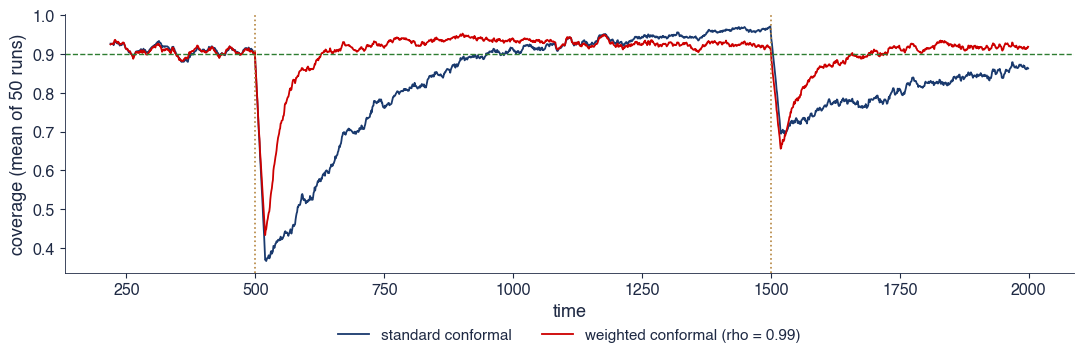

{'standard': {'cov': 0.8366111111111116, 'after': 0.7296000000000005, 'w': 6.215654925193597, 'min': 0.36600000000000005}, 'weighted': {'cov': 0.900144444444445, 'after': 0.7838000000000005, 'w': 7.463144918429973, 'min': 0.4330000000000001}}


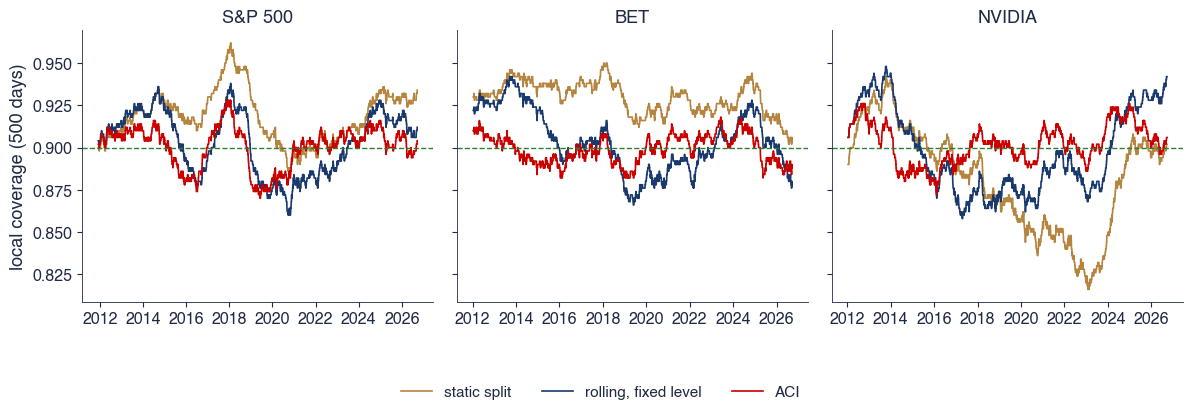

{'sp500': {'static': {'cov': 0.9181300427147603, 'lc_min': 0.884, 'lc_max': 0.962, 'kup': 5.3991832315446136e-05, 'cc': 0.00029076406027448413, 'inf': 0.0}, 'rolling': {'cov': 0.9034171808258187, 'lc_min': 0.86, 'lc_max': 0.938, 'kup': 0.4573457709879296, 'cc': 0.7560730049992291, 'inf': 0.0}, 'aci': {'cov': 0.9005695301376364, 'lc_min': 0.87, 'lc_max': 0.928, 'kup': 0.9018365261192461, 'cc': 0.9676422929729876, 'inf': 0.0}, 'n': 4214, 'first': '2009-12-15', 'last': '2026-09-18'}, 'bet': {'static': {'cov': 0.9282973621103118, 'lc_min': 0.902, 'lc_max': 0.95, 'kup': 1.7286971187562482e-10, 'cc': 1.2352222229191458e-09, 'inf': 0.0}, 'rolling': {'cov': 0.9026378896882494, 'lc_min': 0.866, 'lc_max': 0.942, 'kup': 0.5686402678222445, 'cc': 0.8486697781925099, 'inf': 0.0}, 'aci': {'cov': 0.8990407673860912, 'lc_min': 0.882, 'lc_max': 0.918, 'kup': 0.8366469286329721, 'cc': 0.8906721511998175, 'inf': 0.0}, 'n': 4170, 'first': '2010-01-27', 'last': '2026-09-18'}, 'nvda': {'static': {'cov': 0.8

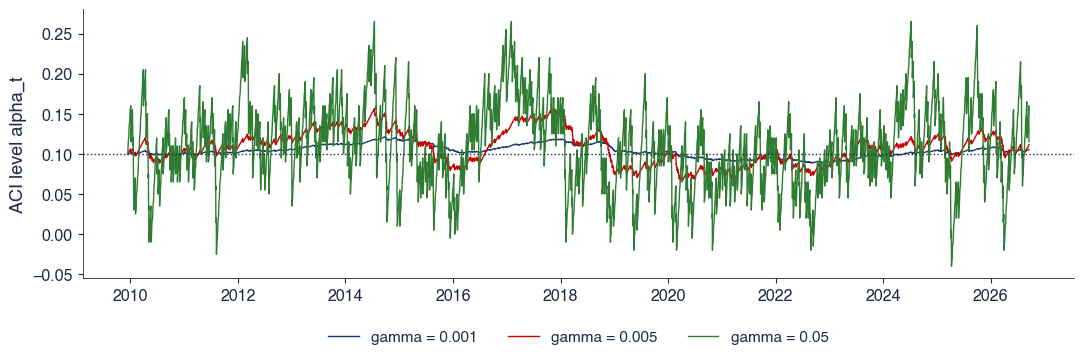

{'0.001': {'miss': 0.09871855719031798, 'bound': 0.2138111058376839, 'inf': 0.0, 'amin': 0.08860000000000887, 'amax': 0.12120000000000336, 'jitter': 0.014970548290840041, 'T': 4214}, '0.005': {'miss': 0.09943046986236355, 'bound': 0.042952064546748936, 'inf': 0.0, 'amin': 0.06649999999999998, 'amax': 0.15700000000000006, 'jitter': 0.03731318172406036, 'T': 4214}, '0.05': {'miss': 0.09990507831039393, 'bound': 0.004508780256288562, 'inf': 0.01589938300901756, 'amin': -0.039999999999989946, 'amax': 0.2650000000000096, 'jitter': 0.7988177138377566, 'T': 4214}}


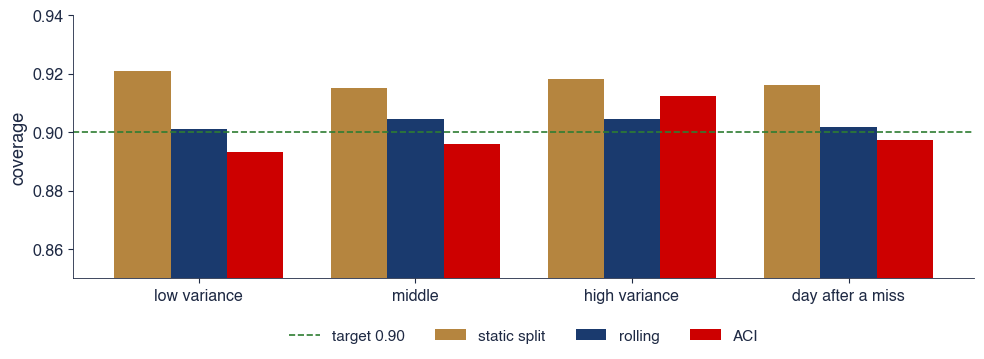

{'static': [0.9209964412811388, 0.9152421652421653, 0.9181494661921709, 0.9159420289855073], 'rolling': [0.901067615658363, 0.9045584045584045, 0.904626334519573, 0.9017199017199017], 'aci': [0.8932384341637011, 0.896011396011396, 0.9124555160142349, 0.8973747016706444]}


In [14]:
def fig_weighted(save_it=True, n=2000, burn=200, rho=0.99, alpha=0.1, reps=200, seed=SEED):
    """Weighted (non-exchangeable) conformal prediction against standard conformal under changepoints, in the style
    of the simulations of Barber et al. (2023): Y = X'beta_t + N(0, 1), X ~ N(0, I_4), beta changes at t = 500 and
    1500; least squares refitted on all past data; prequential absolute residuals as scores; weights rho^(t - i).
    Coverage of each time point averaged over `reps` replications."""
    rng = np.random.default_rng(seed)
    b1, b2, b3 = np.array([2, 1, 0, 0.]), np.array([0, -2, -1, 0.]), np.array([0, 0, 2, 1.])
    covs = {'standard': np.zeros(n), 'weighted': np.zeros(n)}
    width = {'standard': np.zeros(n), 'weighted': np.zeros(n)}
    for _ in range(reps):
        X = rng.standard_normal((n, 4))
        B = np.where(np.arange(n)[:, None] < 500, b1, np.where(np.arange(n)[:, None] < 1500, b2, b3))
        Y = (X * B).sum(1) + rng.standard_normal(n)
        S = np.full(n, np.nan)
        XtX, Xty = np.eye(4) * 1e-6, np.zeros(4)
        for t in range(n):
            if t >= 10:
                S[t] = abs(Y[t] - X[t] @ np.linalg.solve(XtX, Xty))
            XtX += np.outer(X[t], X[t])
            Xty += X[t] * Y[t]
        for meth in covs:
            q, _ = online_threshold(S[10:], alpha, method='rolling' if meth == 'standard' else 'weighted', rho=rho,
                                    start=burn - 10)
            q = np.r_[np.full(10, np.nan), q]
            covs[meth] += (S <= q) / reps
            width[meth] += np.where(np.isfinite(q), 2 * q, np.nan) / reps
    fig, ax = plt.subplots(figsize=(11, 3.8))
    t = np.arange(n)
    for meth, col in (('standard', st.MainBlue), ('weighted', st.IDAred)):
        ax.plot(t[burn:], pd.Series(covs[meth][burn:]).rolling(20).mean(), color=col, lw=1.3,
                label=f'{meth} conformal' + (f' (rho = {rho})' if meth == 'weighted' else ''))
    ax.axhline(1 - alpha, color=st.Forest, ls='--', lw=1)
    for c in (500, 1500):
        ax.axvline(c, color=st.Amber, ls=':', lw=1.2)
    ax.set_xlabel('time')
    ax.set_ylabel(f'coverage (mean of {reps} runs)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_weighted', save_it)
    after = slice(1500, 1600)
    return {m: dict(cov=float(np.mean(covs[m][burn:])), after=float(np.mean(covs[m][after])),
                    w=float(np.nanmean(width[m][burn:])), min=float(pd.Series(covs[m][burn:]).rolling(20).mean().min()))
            for m in covs}


def garch_scores(name, start=None, fit_win=1250, refit=20):
    """The design of Gibbs and Candes (2021) for stock volatility: V_t = r_t^2, sigma_t^2 from a GARCH(1,1) fitted on
    the previous fit_win days (re-estimated every `refit` days, filtered daily), score S_t = |V_t - sigma_t^2| /
    sigma_t^2. Returns dates, scores, sigma2, returns (from `start`)."""
    key = f'gs_{name}'
    if key in _MEM:
        return _MEM[key]
    start = start or GS_START
    r = log_returns(name)
    i0 = max(int(np.searchsorted(r.index, pd.Timestamp(start))), fit_win)
    rr = r.values
    sig2 = np.full(len(rr), np.nan)
    par = None
    for t in range(i0, len(rr)):
        if par is None or (t - i0) % refit == 0:
            par = garch11_fit(rr[t - fit_win:t], dist='normal')
        sig2[t] = garch11_filter(rr[t - fit_win:t], par)[-1]
    sl = slice(i0, len(rr))
    S = np.abs(rr[sl] ** 2 - sig2[sl]) / sig2[sl]
    _MEM[key] = (r.index[sl], S, sig2[sl], rr[sl])
    return _MEM[key]


def local_cov(miss, w=500):
    """Rolling coverage over the last w points (the local coverage frequency of Gibbs and Candes 2021)."""
    return 1 - pd.Series(miss).rolling(w).mean().values


def fig_aci(save_it=True, alpha=0.1, gamma=0.005, n_cal=1250):
    """S&P 500, BET and NVIDIA: local coverage (two-year window) of 90% volatility intervals: static split conformal
    (calibrated once on the first 1250 scores), rolling split conformal with a fixed level and ACI (gamma = 0.005)."""
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
    out = {}
    for ax, nm, lab in zip(axs, ('sp500', 'bet', 'nvda'), ('S&P 500', 'BET', 'NVIDIA')):
        dates, S, s2, r = garch_scores(nm)
        res = {}
        for meth, col, lb in (('static', st.Amber, 'static split'), ('rolling', st.MainBlue, 'rolling, fixed level'),
                              ('aci', st.IDAred, 'ACI')):
            q, at = online_threshold(S, alpha, method=meth, n_cal=n_cal, window=n_cal, gamma=gamma)
            miss = (S > q)[n_cal:].astype(float)
            lc = local_cov(miss)
            ax.plot(dates[n_cal:], lc, color=col, lw=1.2, label=lb)
            hits = miss
            res[meth] = dict(cov=float(1 - miss.mean()), lc_min=float(np.nanmin(lc)), lc_max=float(np.nanmax(lc)),
                             kup=kupiec(hits, alpha)[1], cc=christoffersen(hits, alpha)['p_cc'],
                             inf=float(np.mean(np.isinf(q[n_cal:]))))
        ax.axhline(1 - alpha, color=st.Forest, ls='--', lw=1)
        ax.set_title(lab)
        out[nm] = dict(res, n=int(len(S) - n_cal), first=str(dates[n_cal].date()), last=str(dates[-1].date()))
    axs[0].set_ylabel('local coverage (500 days)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch13_aci', save_it)
    return out


def fig_aci_gamma(save_it=True, alpha=0.1, n_cal=1250):
    """ACI on the S&P 500 scores: the level alpha_t for gamma = 0.001, 0.005, 0.05; long-run miss rate, its bound
    (max(alpha_1, 1 - alpha_1) + gamma) / (gamma T), interval instability (s.d. of the threshold changes) and the
    share of infinite intervals."""
    dates, S, s2, r = garch_scores('sp500')
    fig, ax = plt.subplots(figsize=(11, 3.8))
    out = {}
    for g, col in ((0.001, st.MainBlue), (0.005, st.IDAred), (0.05, st.Forest)):
        q, at = online_threshold(S, alpha, method='aci', n_cal=n_cal, window=n_cal, gamma=g)
        miss = (S > q)[n_cal:]
        T = len(miss)
        ax.plot(dates[n_cal:], at[n_cal:], color=col, lw=1.0, label=f'gamma = {g}')
        qq = q[n_cal:][np.isfinite(q[n_cal:])]
        out[str(g)] = dict(miss=float(miss.mean()), bound=float((max(alpha, 1 - alpha) + g) / (g * T)),
                           inf=float(np.mean(np.isinf(q[n_cal:]))), amin=float(np.nanmin(at[n_cal:])),
                           amax=float(np.nanmax(at[n_cal:])), jitter=float(np.std(np.diff(qq))), T=T)
    ax.axhline(alpha, color=st.DarkText, ls=':', lw=1)
    ax.set_ylabel('ACI level alpha_t')
    st.legend_outside_bottom(ax, ncol=3, y=-0.14)
    plt.tight_layout()
    save('ats_ch13_aci_gamma', save_it)
    return out


def fig_condcov(save_it=True, alpha=0.1, n_cal=1250):
    """Conditional coverage on the S&P 500: coverage of the static, rolling and ACI intervals by tercile of the GARCH
    variance forecast and in the days after a miss (the dependence the Christoffersen test detects)."""
    dates, S, s2, r = garch_scores('sp500')
    terc = pd.qcut(s2[n_cal:], 3, labels=False)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    out = {}
    labs = ['low variance', 'middle', 'high variance', 'day after a miss']
    for j, (meth, col, lb) in enumerate((('static', st.Amber, 'static split'), ('rolling', st.MainBlue, 'rolling'),
                                         ('aci', st.IDAred, 'ACI'))):
        q, _ = online_threshold(S, alpha, method=meth, n_cal=n_cal, window=n_cal, gamma=0.005)
        cov = (S <= q)[n_cal:]
        v = [float(cov[terc == k].mean()) for k in range(3)] + [float(cov[1:][~cov[:-1]].mean())]
        ax.bar(np.arange(4) + (j - 1) * 0.26, v, width=0.26, color=col, label=lb)
        out[meth] = v
    ax.axhline(1 - alpha, color=st.Forest, ls='--', lw=1.2, label='target 0.90')
    ax.set_xticks(range(4))
    ax.set_xticklabels(labs)
    ax.set_ylim(0.85, 0.94)
    ax.set_ylabel('coverage')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    plt.tight_layout()
    save('ats_ch13_condcov', save_it)
    return out


print(fig_weighted(save_it=False, reps=50))
print(fig_aci(save_it=False))
print(fig_aci_gamma(save_it=False))
print(fig_condcov(save_it=False))

## 9. Quantile tracking, conformal PID and EnbPI on Romanian load

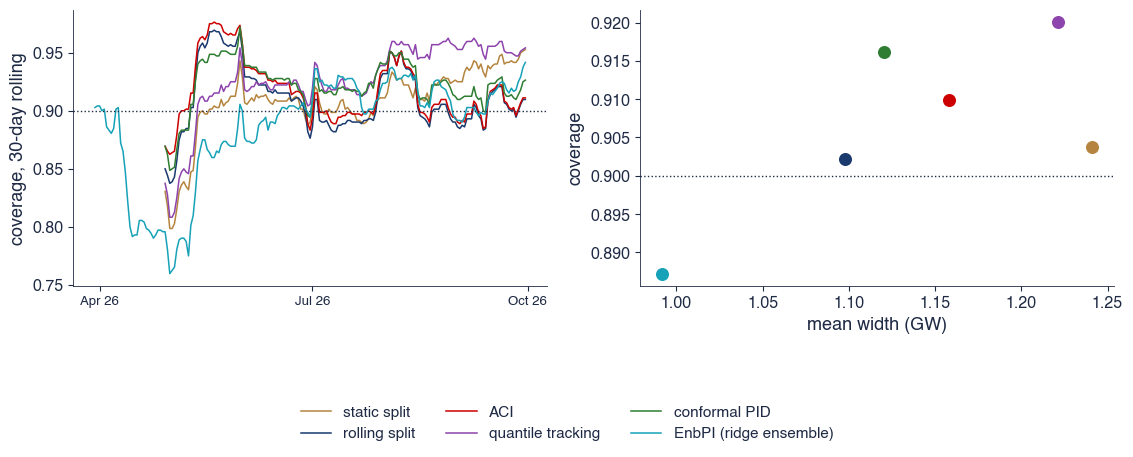

{'static': {'cov': 0.9037590579710145, 'width': 1.2410525960922243, 'lc_min': 0.7986111111111112}, 'rolling': {'cov': 0.9021739130434783, 'width': 1.0975430746570878, 'lc_min': 0.8375}, 'aci': {'cov': 0.9098731884057971, 'width': 1.1578967119965, 'lc_min': 0.8625}, 'qt': {'cov': 0.9200634057971014, 'width': 1.2214118097047428, 'lc_min': 0.8083333333333333}, 'pid': {'cov': 0.916213768115942, 'width': 1.1203887305660478, 'lc_min': 0.8486111111111111}, 'enbpi': {'cov': 0.8872282608695652, 'width': 0.9914396987249817, 'lc_min': 0.7597222222222222}, 'base': 'Chronos-Bolt small', 'first': '2026-03-31'}


In [15]:
def load_scores(base='expert ARX'):
    """Hour-by-hour streams of absolute day-ahead errors of a base forecaster (days x 24) on Romanian load."""
    days, A, P, Q = load_all()
    return days, A, P[base], np.abs(A - P[base])


def fig_pid(save_it=True, alpha=0.1, n_cal=91, base='Chronos-Bolt small'):
    """90% day-ahead intervals for Romanian load around a base point forecast, one online threshold per hour of the
    day: static split (first n_cal days), rolling split (last n_cal days), ACI, quantile tracking, conformal PID
    (quantile tracking + integrator + AR(1) scorecaster) and EnbPI on the expert ARX regressors."""
    days, A, P, S = load_scores(base)
    nD = len(days)
    meths = [('static', 'static split'), ('rolling', 'rolling split'), ('aci', 'ACI'), ('qt', 'quantile tracking'),
             ('pid', 'conformal PID')]
    miss = {m: np.full((nD, 24), np.nan) for m, _ in meths}
    wid = {m: np.full((nD, 24), np.nan) for m, _ in meths}
    for h in range(24):
        s = S[:, h]
        for m, _ in meths:
            q, _ = online_threshold(s, alpha, method=m, n_cal=n_cal, window=n_cal, gamma=0.005,
                                    scorecaster=ar_scorecaster(1, 365) if m == 'pid' else None)
            miss[m][n_cal:, h] = (s > q)[n_cal:]
            wid[m][n_cal:, h] = 2 * q[n_cal:]
    # EnbPI on the expert ARX regressors, one stream per hour
    Y = ro_load_hourly()
    dd, AA = Y.index, Y.values
    dow = np.array([d.dayofweek for d in dd])
    st0 = int(np.searchsorted(dd, days[0])) - 365
    em, ew = np.full((nD, 24), np.nan), np.full((nD, 24), np.nan)
    mins, maxs, last = AA.min(1), AA.max(1), AA[:, 23]
    for h in range(24):
        rows = np.arange(st0, len(dd))
        X = np.column_stack([AA[rows - 1, h], AA[rows - 2, h], AA[rows - 7, h], mins[rows - 1], maxs[rows - 1],
                             last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6]).astype(float)
        c, hw = enbpi(X, AA[rows, h], 365, alpha, B=20, block=7, seed=SEED)
        em[:, h] = np.abs(AA[rows[365:], h] - c) > hw
        ew[:, h] = 2 * hw
    miss['enbpi'], wid['enbpi'] = em, ew
    meths.append(('enbpi', 'EnbPI (ridge ensemble)'))
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    out = {}
    cols = {'static': st.Amber, 'rolling': st.MainBlue, 'aci': st.IDAred, 'qt': st.Purple, 'pid': st.Forest, 'enbpi': st.Teal}
    for m, lb in meths:
        mm = np.nanmean(miss[m], axis=1)
        lc = 1 - pd.Series(mm).rolling(30).mean()
        axs[0].plot(days, lc, color=cols[m], lw=1.1, label=lb)
        out[m] = dict(cov=float(1 - np.nanmean(miss[m][n_cal:])), width=float(np.nanmean(wid[m][n_cal:])),
                      lc_min=float(np.nanmin(lc[n_cal:])))
        axs[1].scatter(out[m]['width'], out[m]['cov'], color=cols[m], s=70)
    axs[0].axhline(1 - alpha, color=st.DarkText, ls=':', lw=1)
    axs[0].set_ylabel('coverage, 30-day rolling')
    import matplotlib.dates as mdates
    axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
    axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    axs[0].tick_params(axis='x', labelsize=9.5)
    axs[1].axhline(1 - alpha, color=st.DarkText, ls=':', lw=1)
    axs[1].set_xlabel('mean width (GW)')
    axs[1].set_ylabel('coverage')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch13_pid', save_it)
    out['base'] = base
    out['first'] = str(days[n_cal].date())
    return out


print(fig_pid(save_it=False, n_cal=30))

## 10. Calibrating foundation-model intervals and VaR

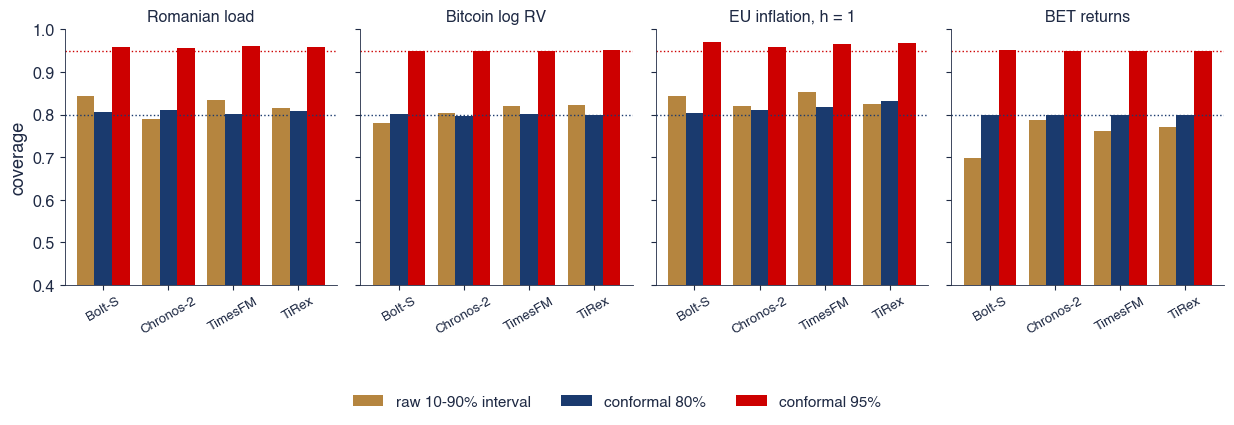

{'load': {'Chronos-Bolt small': {'raw': 0.8430735930735931, 'c80': 0.8060064935064936, 'c95': 0.9583333333333334, 'wratio': 1.0295325984179486}, 'Chronos-2': {'raw': 0.7892316017316018, 'c80': 0.8108766233766234, 'c95': 0.9564393939393939, 'wratio': 1.100877948292}, 'TimesFM 2.5': {'raw': 0.8352272727272727, 'c80': 0.8016774891774892, 'c95': 0.9618506493506493, 'wratio': 1.0562330437059924}, 'TiRex': {'raw': 0.814935064935065, 'c80': 0.8087121212121212, 'c95': 0.9594155844155844, 'wratio': 1.059937878105789}}, 'btc': {'Chronos-Bolt small': {'raw': 0.7802056555269923, 'c80': 0.800771208226221, 'c95': 0.9498714652956298, 'wratio': 1.0719026627904629}, 'Chronos-2': {'raw': 0.8046272493573264, 'c80': 0.7969151670951157, 'c95': 0.9498714652956298, 'wratio': 1.0068721181027083}, 'TimesFM 2.5': {'raw': 0.8200514138817481, 'c80': 0.800771208226221, 'c95': 0.9498714652956298, 'wratio': 0.9623564258039529}, 'TiRex': {'raw': 0.8226221079691517, 'c80': 0.7994858611825193, 'c95': 0.9511568123393316

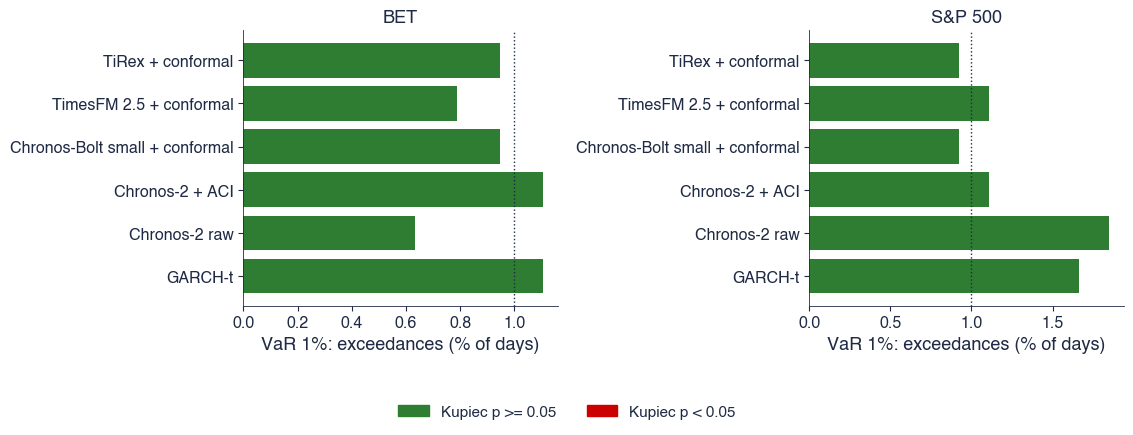

{'bet': {'0.01': {'GARCH-t': {'hit': 0.011058451816745656, 'kup': 0.7924240727968417, 'cc': 0.8921617066554324, 'loss': 0.02999044382513731, 'dm': nan, 'dmp': nan}, 'Chronos-2 raw': {'hit': 0.00631911532385466, 'kup': 0.3181333042294004, 'cc': 0.5944763024695436, 'loss': 0.029055764832198818, 'dm': -0.6697530440481134, 'dmp': 0.5032598474257906}, 'Chronos-2 + ACI': {'hit': 0.011058451816745656, 'kup': 0.7924240727968417, 'cc': 0.8921617066554324, 'loss': 0.03337049835044335, 'dm': 1.8989284964209718, 'dmp': 0.058029020882136226}, 'Chronos-Bolt small + conformal': {'hit': 0.009478672985781991, 'kup': 0.8942066355482219, 'cc': 0.9362879123000035, 'loss': 0.030095785917310474, 'dm': 0.05073209446722809, 'dmp': 0.9595550312731824}, 'TimesFM 2.5 + conformal': {'hit': 0.007898894154818325, 'kup': 0.5812628743657164, 'cc': 0.8270767531093581, 'loss': 0.030858913791794465, 'dm': 0.4502375277686733, 'dmp': 0.6526935790400649}, 'TiRex + conformal': {'hit': 0.009478672985781991, 'kup': 0.89420663

In [16]:
def returns_fm(name, first=None, ctx=1024):
    """Daily log returns (%) and one-day-ahead quantile forecasts of the foundation models at the levels
    0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99 (NaN where a model was not trained on that level)."""
    key = f'ret_{name}'
    if key in _MEM:
        return _MEM[key]
    first = first or RET_FIRST
    r = log_returns(name)
    i0 = int(np.searchsorted(r.index, pd.Timestamp(first)))
    C = [r.values[t - ctx:t] for t in range(i0, len(r))]
    taus = [0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]
    out = {}
    for nm in FMS:
        Q = fm_cached(f'{key}_{first}_{ctx}', nm, C, 1, taus)
        if Q is not None:
            out[nm] = Q[:, 0, :]
    _MEM[key] = (r.index[i0:], r.values[i0:], out)
    return _MEM[key]


def garch_var(name, first=None, win=1000, refit=250, levels=(0.01, 0.05)):
    """VaR from a GARCH(1,1)-t on a rolling window of `win` days re-estimated every `refit` days (Chapter 9):
    the alpha-quantile of the one-day-ahead predictive distribution (VaR_alpha = -q_alpha)."""
    from scipy import stats as _s
    first = first or RET_FIRST
    r = log_returns(name)
    i0 = int(np.searchsorted(r.index, pd.Timestamp(first)))
    rr = r.values
    Qv = np.full((len(rr) - i0, len(levels)), np.nan)
    par = None
    for j, t in enumerate(range(i0, len(rr))):
        if par is None or j % refit == 0:
            par = garch11_fit(rr[t - win:t], dist='t')
        h = garch11_filter(rr[t - win:t], par)[-1]
        nu = par[3]
        Qv[j] = np.sqrt(h * (nu - 2) / nu) * _s.t.ppf(levels, nu)
    return Qv


def fig_fm_calib(save_it=True, w=250, gamma=0.005, w_infl=60):
    """Coverage of the raw 80% intervals (10% and 90% quantiles) of the foundation models and after online CQR:
    80% and 95% intervals from the score max(q10 - y, y - q90) with an ACI threshold on the last w scores (w_infl for
    the monthly inflation streams). Tasks:
    Romanian load (hour by hour), Bitcoin log RV, EU inflation (h = 1, country by country), BET returns."""
    tasks = {}
    days, A, P, Q = load_all()
    tasks['load'] = {k: [(A[:, h], Q[k][:, h, 0], Q[k][:, h, 8]) for h in range(24)] for k in FMS if k in Q}
    d, rv, x, F = rv_forecasts('btc')
    tasks['btc'] = {k: [(x, F[k][2][:, 0], F[k][2][:, 8])] for k in FMS if k in F}
    dates, origins, act, FI = infl_forecasts()
    tasks['infl'] = {k: [(act[:, c, 0], FI[k][1][:, c, 0, 0], FI[k][1][:, c, 0, 8]) for c in range(len(EU27))]
                     for k in FMS if k in FI}
    rd, rr, RQ = returns_fm('bet')
    tasks['bet'] = {k: [(rr, RQ[k][:, 2], RQ[k][:, -3])] for k in FMS if k in RQ}
    out = {}
    W = {'load': w, 'btc': w, 'infl': w_infl, 'bet': w}           # inflation: 27 short monthly streams
    for tk, M in tasks.items():
        out[tk] = {}
        w = W[tk]
        for k, streams in M.items():
            raw, c80, c95, wd80, wraw = [], [], [], [], []
            for y, lo, hi in streams:
                ok = ~np.isnan(y)
                y, lo, hi = y[ok], lo[ok], hi[ok]
                s = np.maximum(lo - y, y - hi)
                raw.append((s <= 0)[w:])
                for a, lst in ((0.2, c80), (0.05, c95)):
                    q, _ = online_threshold(s, a, method='aci', n_cal=w, window=w, gamma=gamma)
                    lst.append((s <= q)[w:])
                    if a == 0.2:
                        qq = np.where(np.isfinite(q[w:]), q[w:], np.nan)
                        wd80.append(np.nanmean(hi[w:] - lo[w:] + 2 * qq))
                        wraw.append(np.mean(hi[w:] - lo[w:]))
            out[tk][k] = dict(raw=float(np.mean(np.concatenate(raw))), c80=float(np.mean(np.concatenate(c80))),
                              c95=float(np.mean(np.concatenate(c95))), wratio=float(np.mean(wd80) / np.mean(wraw)))
    fig, axs = plt.subplots(1, 4, figsize=(12.5, 3.9), sharey=True)
    ttl = {'load': 'Romanian load', 'btc': 'Bitcoin log RV', 'infl': 'EU inflation, h = 1', 'bet': 'BET returns'}
    for ax, tk in zip(axs, out):
        ks = list(out[tk])
        x0 = np.arange(len(ks))
        for j, (f, col, lb) in enumerate((('raw', st.Amber, 'raw 10-90% interval'), ('c80', st.MainBlue, 'conformal 80%'),
                                          ('c95', st.IDAred, 'conformal 95%'))):
            ax.bar(x0 + (j - 1) * 0.27, [out[tk][k][f] for k in ks], width=0.27, color=col, label=lb)
        ax.axhline(0.8, color=st.MainBlue, ls=':', lw=1)
        ax.axhline(0.95, color=st.IDAred, ls=':', lw=1)
        ax.set_xticks(x0)
        ax.set_xticklabels([k.replace('Chronos-Bolt small', 'Bolt-S').replace('TimesFM 2.5', 'TimesFM') for k in ks],
                           rotation=30, fontsize=9.5)
        ax.set_title(ttl[tk], fontsize=11.5)
        ax.set_ylim(0.4, 1.0)
    axs[0].set_ylabel('coverage')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch13_fm_calib', save_it)
    return out


def fig_fm_var(save_it=True, w=500, gamma=0.005):
    """VaR 1% and 5% of the BET and the S&P 500, 2016-2026: GARCH-t; Chronos-2 raw quantiles; Chronos-2 + ACI; the
    deciles of Chronos-Bolt, TimesFM and TiRex extended to 1% and 5% by an online one-sided conformal shift of the
    10% quantile (score q10 - y, ACI threshold on the last w scores). Hit rates, Kupiec and Christoffersen p-values,
    the pinball loss and the DM test against GARCH-t."""
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.0))
    for ax, nm, lab in ((axs[0], 'bet', 'BET'), (axs[1], 'sp500', 'S&P 500')):
        dates, rr, RQ = returns_fm(nm)
        G = garch_var(nm)
        res = {}
        for a, ka in ((0.01, 0), (0.05, 1)):
            V = {'GARCH-t': G[:, ka]}
            if 'Chronos-2' in RQ:
                V['Chronos-2 raw'] = RQ['Chronos-2'][:, ka]
                s = RQ['Chronos-2'][:, ka] - rr
                q, _ = online_threshold(s, a, method='aci', n_cal=w, window=w, gamma=gamma)
                V['Chronos-2 + ACI'] = RQ['Chronos-2'][:, ka] - np.where(np.isfinite(q), q, np.nan)
            for k in ('Chronos-Bolt small', 'TimesFM 2.5', 'TiRex'):
                if k in RQ:
                    s = RQ[k][:, 2] - rr
                    q, _ = online_threshold(s, a, method='aci', n_cal=w, window=w, gamma=gamma)
                    V[k + ' + conformal'] = RQ[k][:, 2] - np.where(np.isfinite(q), q, np.nan)
            ok = np.all([~np.isnan(v) for v in V.values()], axis=0)
            ok[:w] = False
            rs = {}
            base = pinball(rr[ok], V['GARCH-t'][ok], a)
            for k, v in V.items():
                hit = (rr[ok] < v[ok]).astype(float)
                pl = pinball(rr[ok], v[ok], a)
                rs[k] = dict(hit=float(hit.mean()), kup=kupiec(hit, a)[1], cc=christoffersen(hit, a)['p_cc'],
                             loss=float(pl.mean()), dm=dm_test(pl - base, 1)['hln'], dmp=dm_test(pl - base, 1)['p'])
            res[str(a)] = rs
            res['n'] = int(ok.sum())
            res['first'] = str(dates[ok][0].date())
            if a == 0.01:
                ks = list(rs)
                y = np.arange(len(ks))
                ax.barh(y, [100 * rs[k]['hit'] for k in ks], color=[st.Forest if rs[k]['kup'] >= 0.05 else st.IDAred for k in ks])
                ax.set_yticks(y)
                ax.set_yticklabels(ks)
                ax.axvline(1, color=st.DarkText, ls=':', lw=1)
                ax.set_xlabel('VaR 1%: exceedances (% of days)')
                ax.set_title(lab)
        out[nm] = res
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=st.Forest, label='Kupiec p >= 0.05'), Patch(color=st.IDAred, label='Kupiec p < 0.05')],
               loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    save('ats_ch13_fm_var', save_it)
    return out


print(fig_fm_calib(save_it=False, w=60, w_infl=24))
print(fig_fm_var(save_it=False, w=250))

## 11. AI mini-case: how much can the choice of benchmark change the verdict?

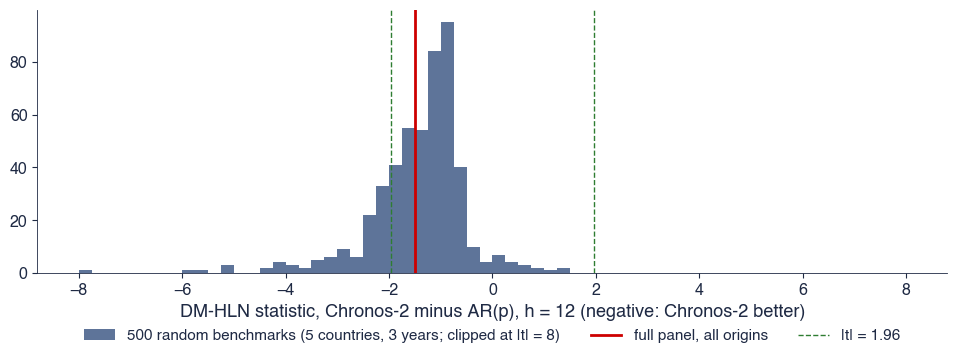

{'win': 0.192, 'lose': 0.0, 'full_t': -1.4947798134234596, 'full_p': 0.14227506740822315, 'reps': 500, 'k': 5, 'years': 3}


In [17]:
def fig_ai_case(save_it=True, model='Chronos-2', k=5, years=3, reps=2000, h=12):
    """How often does a random 'benchmark' (k countries, one window of `years` years of origins) make a foundation
    model look significantly better, or significantly worse, than AR(p)? Pooled DM-HLN on the h-step absolute errors
    of the subset; the full-panel verdict for comparison."""
    dates, origins, act, F = infl_forecasts()
    od = dates[origins]
    D = np.abs(act[:, :, h - 1] - F[model][0][:, :, h - 1]) - np.abs(act[:, :, h - 1] - F['AR(p)'][0][:, :, h - 1])
    valid = ~np.isnan(D).any(axis=1)
    rng = np.random.default_rng(SEED)
    yrs = sorted(set(od[valid].year))
    stats_ = []
    for _ in range(reps):
        cs = rng.choice(len(EU27), k, replace=False)
        y0 = rng.choice(yrs[:len(yrs) - years + 1])
        m = valid & (od.year >= y0) & (od.year < y0 + years)
        d = D[m][:, cs].mean(axis=1)
        r = dm_test(d, h)
        stats_.append((r['hln'], r['p']))
    t = np.array([s[0] for s in stats_])
    p = np.array([s[1] for s in stats_])
    full = dm_test(D[valid].mean(axis=1), h)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    tc = np.clip(t, -8, 8)
    ax.hist(tc, bins=64, range=(-8, 8), color=st.MainBlue, alpha=0.7,
            label=f'{reps} random benchmarks ({k} countries, {years} years; clipped at |t| = 8)')
    ax.axvline(full['hln'], color=st.IDAred, lw=2, label='full panel, all origins')
    ax.axvline(-1.96, color=st.Forest, ls='--', lw=1, label='|t| = 1.96')
    ax.axvline(1.96, color=st.Forest, ls='--', lw=1)
    ax.set_xlabel(f'DM-HLN statistic, {model} minus AR(p), h = {h} (negative: {model} better)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save('ats_ch13_ai_case', save_it)
    return dict(win=float(((p < 0.05) & (t < 0)).mean()), lose=float(((p < 0.05) & (t > 0)).mean()),
                full_t=full['hln'], full_p=full['p'], reps=reps, k=k, years=years)


print(fig_ai_case(save_it=False, reps=500))

## Exercises

1. Replace the realised temperature in `fig_covariates` by a temperature forecast available at the origin (for example a seasonal mean of the same hour and day of the year) and measure how much of the gain remains.
2. Add Moirai or another open model to `FM_SPECS` and to `fm_forecast`, and rerun the inflation panel.
3. Replace the score of the ACI volatility design by one normalised with the realised variance of the previous day and compare conditional coverage by volatility tercile.